
# Wstęp

## Cel ćwiczenia

Celem ćwiczenia jest **wytrenowanie od podstaw sieci typu MLP (Multi-Layer Perceptron)** oraz **analiza wpływu wybranych dobrych praktyk** stosowanych w deep learningu na proces uczenia i jakość uzyskiwanych wyników.
W trakcie zadania będziemy świadomie podejmować decyzje projektowe dotyczące architektury, przygotowania danych oraz procesu treningu.


# Ogólne informacje do zadania

### 1. Zbiór danych

W zadaniu wykorzystany zostanie zbiór **FashionMNIST**, który jest dostępny domyślnie w bibliotece `torchvision`.

Przy pierwszym uruchomieniu notebooka zbiór danych zostanie pobrany na dysk lokalny.
W tym celu należy ustawić flagę `download=True` oraz wskazać odpowiednią ścieżkę w parametrze `root`.

> **Uwaga:**
> W przypadku korzystania z Google Colab zaleca się podłączenie Google Drive, aby uniknąć ponownego pobierania danych przy każdym uruchomieniu środowiska.

Przykładowy kod do pobrania danych (można go modyfikować):

```python
from torchvision import datasets

trainset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
```

Zbiór FashionMNIST służy do **klasyfikacji obrazów należących do 10 różnych klas odpowiadającym elementom garderoby** (np. koszulka, płaszcz, but itp).
Nie jest to zbiór przesadnie trudny, natomiast jego plusem jest szybki czas przetwarzania.

### UWAGA
Jeśli ktoś chciałby mieć większe wyzwanie to polecam przeprowadzić rozwiązania na zbiorze [CIFAR10](https://docs.pytorch.org/vision/main/generated/torchvisiondatasets.CIFAR10.html), który nie jest już tak trywialnym zbiorem (dalej ma obrazki i 10 klas, natomiast klasyfikacja jest trudniejsza oraz czas przetwarzania, będzie większy). Jest on również dostępny w `torchvision.datasets` przez co pobiera go się go w analogiczny sposób co MNIST





### 2. Trenowanie sieci MLP

Celem zadania jest wykorzystanie zdobytej wiedzy z zakresu implementacji modeli w **PyTorch** lub **PyTorch Lightning** do wytrenowania sieci składającej się z kilku warstw liniowych (stąd nazwa **Multi-Layer Perceptron**).

Model będzie używany do klasyfikacji obrazów, mimo że:

* dla danych obrazowych **znacznie lepiej sprawdzają się sieci konwolucyjne (CNN)**,
* MLP nie wykorzystuje informacji o strukturze przestrzennej obrazu.

Świadomie ograniczamy się tutaj do MLP, ponieważ:

* pozwala to skupić się na **uniwersalnych dobrych praktykach**, które będą opisane poniżej:
* ułatwia zrozumienie **dlaczego i w jaki sposób CNN przewyższają MLP** w zadaniach wizji komputerowej.

Dopiero po zaobserwowaniu ograniczeń klasycznej sieci MLP możliwe jest pełne docenienie zalet architektur konwolucyjnych, które zostaną omówione w kolejnych zadaniach.

W ramach teorii potrzebnej do zrozumienia na czym polega uczenie sieci MLP, bardzo mocno polecam pierwsze 4 rozdziały z playlist [Neural Networks 3Blue 1Brown](https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi), która w świetny sposób tłumaczy to zagadnienie. Dodatkowo jeśli ktoś nie czuje się do końca dobrze z algorytmem propagacji wstecznej, to również polecam obejrzeć.




### 3. Wykorzystanie dobrych praktyk w trakcie uczenia modelu

W poprzedniej liście zadań trenowaliście **pojedynczy perceptron**, który można uznać za bardzo prostą sieć neuronową.
Proces uczenia polegał głównie na doborze podstawowych hiperparametrów, takich jak:

* liczba epok,
* współczynnik uczenia (*learning rate*).

Dodatkowo wykorzystywany był **zbiór walidacyjny**, który pozwalał obserwować wartość funkcji straty na danych niewidzianych przez model w trakcie uczenia.
Jest to kluczowy element oceny zdolności modelu do **generalizacji**, czyli sprawdzenia, czy model nie uczy się na pamięć danych treningowych (*overfitting*).

W praktycznych zastosowaniach deep learningu stosuje się jednak **szereg dodatkowych technik**, które:

* stabilizują proces uczenia,
* poprawiają generalizację,
* ułatwiają analizę i debugowanie modeli.

W ramach tego zadania będziecie musieli **zrozumieć wszystkie poniższe techniki** oraz przebadać wpływ części z nich na proces uczenia.

---

#### 3.1 Monitorowanie `val_loss` i zapisywanie najlepszego modelu

Podczas treningu wartość straty na zbiorze walidacyjnym (`val_loss`) **nie zawsze maleje monotonicznie**.
Często model osiąga najlepsze wyniki na danych walidacyjnych w pewnej epoce, po czym zaczyna się przeuczać.

Dlatego:

* w trakcie uczenia monitorujemy `val_loss`,
* zapisujemy parametry modelu z epoki, w której `val_loss` było **najniższe**,
* po zakończeniu treningu **ładujemy najlepszy zapisany model**, a nie ten z ostatniej epoki.

**Dlaczego to robimy?**

* minimalizujemy ryzyko overfittingu,
* wykorzystujemy model o najlepszej zdolności generalizacji,
* wynik końcowy nie zależy od arbitralnie dobranej liczby epok.

Technika ta jest często realizowana poprzez tzw. *checkpointing*.

---

#### 3.2 Early stopping

**Early stopping** to mechanizm, który **automatycznie przerywa trening**, jeśli jakość modelu na zbiorze walidacyjnym przestaje się poprawiać.

Działanie:

* obserwujemy `val_loss`,
* jeśli przez określoną liczbę epok (*patience*) nie nastąpi poprawa,
* trening zostaje zakończony.

**Dlaczego to robimy?**

* zapobiegamy przeuczeniu modelu,
* skracamy czas treningu,
* oszczędzamy zasoby obliczeniowe.

Early stopping jest szczególnie skuteczny w połączeniu z **zapisywaniem najlepszego modelu**, ponieważ zapewnia, że końcowy model pochodzi z najlepszego momentu treningu.

**Materiały**
- [Early stopping](https://cyborgcodes.medium.com/what-is-early-stopping-in-deep-learning-eeb1e710a3cf)

---

#### 3.3 Logowanie metryk i funkcji straty

W trakcie treningu należy logować:

* wartość funkcji straty (`loss`),
* metryki jakości (np. accuracy),
* zarówno dla zbioru treningowego, jak i walidacyjnego.

Logowanie może odbywać się:

* do **TensorBoarda**,
* lub w formie danych umożliwiających późniejsze narysowanie wykresów.

**Dlaczego to robimy?**

* umożliwia to wizualną analizę procesu uczenia,
* pozwala szybko wykryć problemy (np. overfitting, zbyt duży learning rate, niestabilne uczenie),
* ułatwia porównywanie różnych eksperymentów i konfiguracji modelu.

W praktyce logowanie jest jednym z podstawowych narzędzi pracy z modelami deep learningowymi.

---

#### 3.4 Regularizacja (L1, L2, Dropout)

Regularizacja ma na celu **ograniczenie nadmiernej złożoności modelu**, co poprawia jego zdolność generalizacji.

* **L1 (Lasso):**

  * dodaje do funkcji straty sumę wartości bezwzględnych wag:

$$
\begin{aligned}
 \lambda \sum_{i} |w_i|
\end{aligned}
$$


  * sprzyja rzadkim rozwiązaniom (wiele wag przyjmuje wartości bliskie zeru).

* **L2 (Ridge / weight decay):**

  * dodaje do funkcji straty sumę kwadratów wag:
$$
\begin{aligned}
    \lambda \sum_{i} w_i^2
\end{aligned}
$$

  * zapobiega nadmiernemu wzrostowi wag,

  * jest najczęściej stosowaną formą regularizacji w deep learningu.

* **Dropout:**

  * w trakcie treningu losowo „wyłącza” część neuronów,
  * zmusza sieć do uczenia się bardziej odpornych reprezentacji,
  * działa jak uśrednianie wielu modeli.

**Dlaczego to robimy?**

* zmniejszamy overfitting,
* poprawiamy stabilność uczenia,
* model lepiej generalizuje na nowe dane.

> **Uwaga:** regularizacja to hiperparametr – jej siłę należy dobrać eksperymentalnie.
> Zbyt silna regularizacja może prowadzić do *underfittingu*.

**Materiały pomocniczne**

* [regularyzacja L1 i L2](https://medium.com/@alejandro.itoaramendia/l1-and-l2-regularization-part-1-a-complete-guide-51cf45bb4ade)
* [dropout](https://medium.com/@piyushkashyap045/understanding-dropout-in-deep-learning-a-guide-to-reducing-overfitting-26cbb68d5575)

---

#### 3.5 Harmonogram uczenia – Cosine Learning Rate Scheduling

Zamiast używać stałego learning rate, często stosuje się **harmonogram jego zmiany w czasie**.

**LR scheduling (np. Cosine Scheduling):**

* learning rate zmniejsza się zgodnie z krzywą cosinusa,
* na początku uczenie jest agresywne,
* pod koniec staje się bardzo delikatne.

Intuicyjnie:

* duży learning rate pomaga szybko znaleźć dobry obszar rozwiązań,
* mały learning rate pozwala dokładnie „dostroić” wagi.

**Dlaczego to robimy?**

* poprawiamy stabilność uczenia,
* często osiągamy lepsze minima funkcji straty,
* zmniejszamy potrzebę ręcznego doboru learning rate.

> W praktyce harmonogram uczenia często ma **większy wpływ na wynik końcowy** niż niewielkie zmiany architektury.

**Materiały**

* [cosine scheduling](https://medium.com/@utkrisht14/cosine-learning-rate-schedulers-in-pytorch-486d8717d541)

---

#### 3.6 Batch Normalization

**Batch Normalization (BatchNorm)** to technika polegająca na **normalizacji aktywacji w warstwach sieci neuronowej** w trakcie treningu.

Dla każdej cechy w mini-batchu:

* odejmowana jest średnia,
* dzielone jest przez odchylenie standardowe,
* a następnie stosowane są uczone parametry skali i przesunięcia.

Intuicyjnie:

* dane „wewnątrz sieci” mają stabilniejszy rozkład,
* kolejne warstwy dostają lepiej uwarunkowane wejście.

**Dlaczego to robimy?**

* stabilizujemy i przyspieszamy proces uczenia,
* umożliwiamy stosowanie większego learning rate,
* zmniejszamy wrażliwość modelu na inicjalizację wag,
* często poprawiamy generalizację (BatchNorm działa częściowo jak regularizacja).

**Ważne uwagi praktyczne:**

* BatchNorm **zachowuje się inaczej w trakcie treningu i inferencji**
  (używa statystyk batcha vs. statystyk zebranych podczas treningu).
* Nie zawsze jest konieczna- w małych sieciach lub przy bardzo małych batchach może **nie przynieść korzyści**.
* BatchNorm **nie jest zamiennikiem regularizacji** (np. Dropoutu), choć czasem może zmniejszyć jej potrzebę.

**Matariały**
- [Batch Normalization](https://medium.com/@piyushkashyap045/understanding-batch-normalization-in-deep-learning-a-beginners-guide-40917c5bebc8)

**UWAGA**
W praktyce nie dodajemy Batch Normalization „w ciemno” do każdej warstwy. Przy części problemów może ona okazać się bardzo pomocna i są pewne architektury które bez niej sobie nie są w stanie poradzić, ale dla prostych problemów jej wpływ może nie być wcale duży. Warto natomiast w każdym przypadku być świadomym, że coś takiego istnieje, ponieważ jest to techina bardzo szeroko stosowana.


# 4. Elementy architektury i treningu, o których należy pamiętać

Poza dobrymi praktykami związanymi z procesem uczenia (takimi jak early stopping, regularizacja czy harmonogram learning rate), istnieją również **podstawowe decyzje projektowe**, które są **ściśle związane z architekturą sieci oraz sposobem jej trenowania**.

Elementy te często mają **istotny wpływ na zbieżność uczenia, stabilność gradientów oraz końcową jakość modelu**, dlatego warto mieć ich istnienie na uwadze — nawet jeśli w tym zadaniu nie będą one głównym obiektem badań.

W szczególności należą do nich:

---

#### 4.1 Funkcje aktywacji

Funkcja aktywacji określa, w jaki sposób sygnał wyjściowy neuronu jest przekształcany i przekazywany do kolejnych warstw.
W praktyce deep learningu najczęściej spotyka się następujące, **bazowe funkcje aktywacji**:

* **Sigmoid**
  Historycznie bardzo popularna, obecnie rzadziej stosowana w warstwach ukrytych ze względu na problem zanikającego gradientu.

* **Tanh**
  Podobna do sigmoidy, ale o wyjściu symetrycznym względem zera; również może prowadzić do problemów z gradientami w głębokich sieciach.

* **ReLU (Rectified Linear Unit)**
  Najczęściej stosowana funkcja aktywacji w nowoczesnych sieciach neuronowych; prosta i skuteczna, sprzyja stabilnemu uczeniu.

Wybór funkcji aktywacji wpływa na dynamikę uczenia i może znacząco zmienić zachowanie modelu, nawet przy tej samej architekturze.


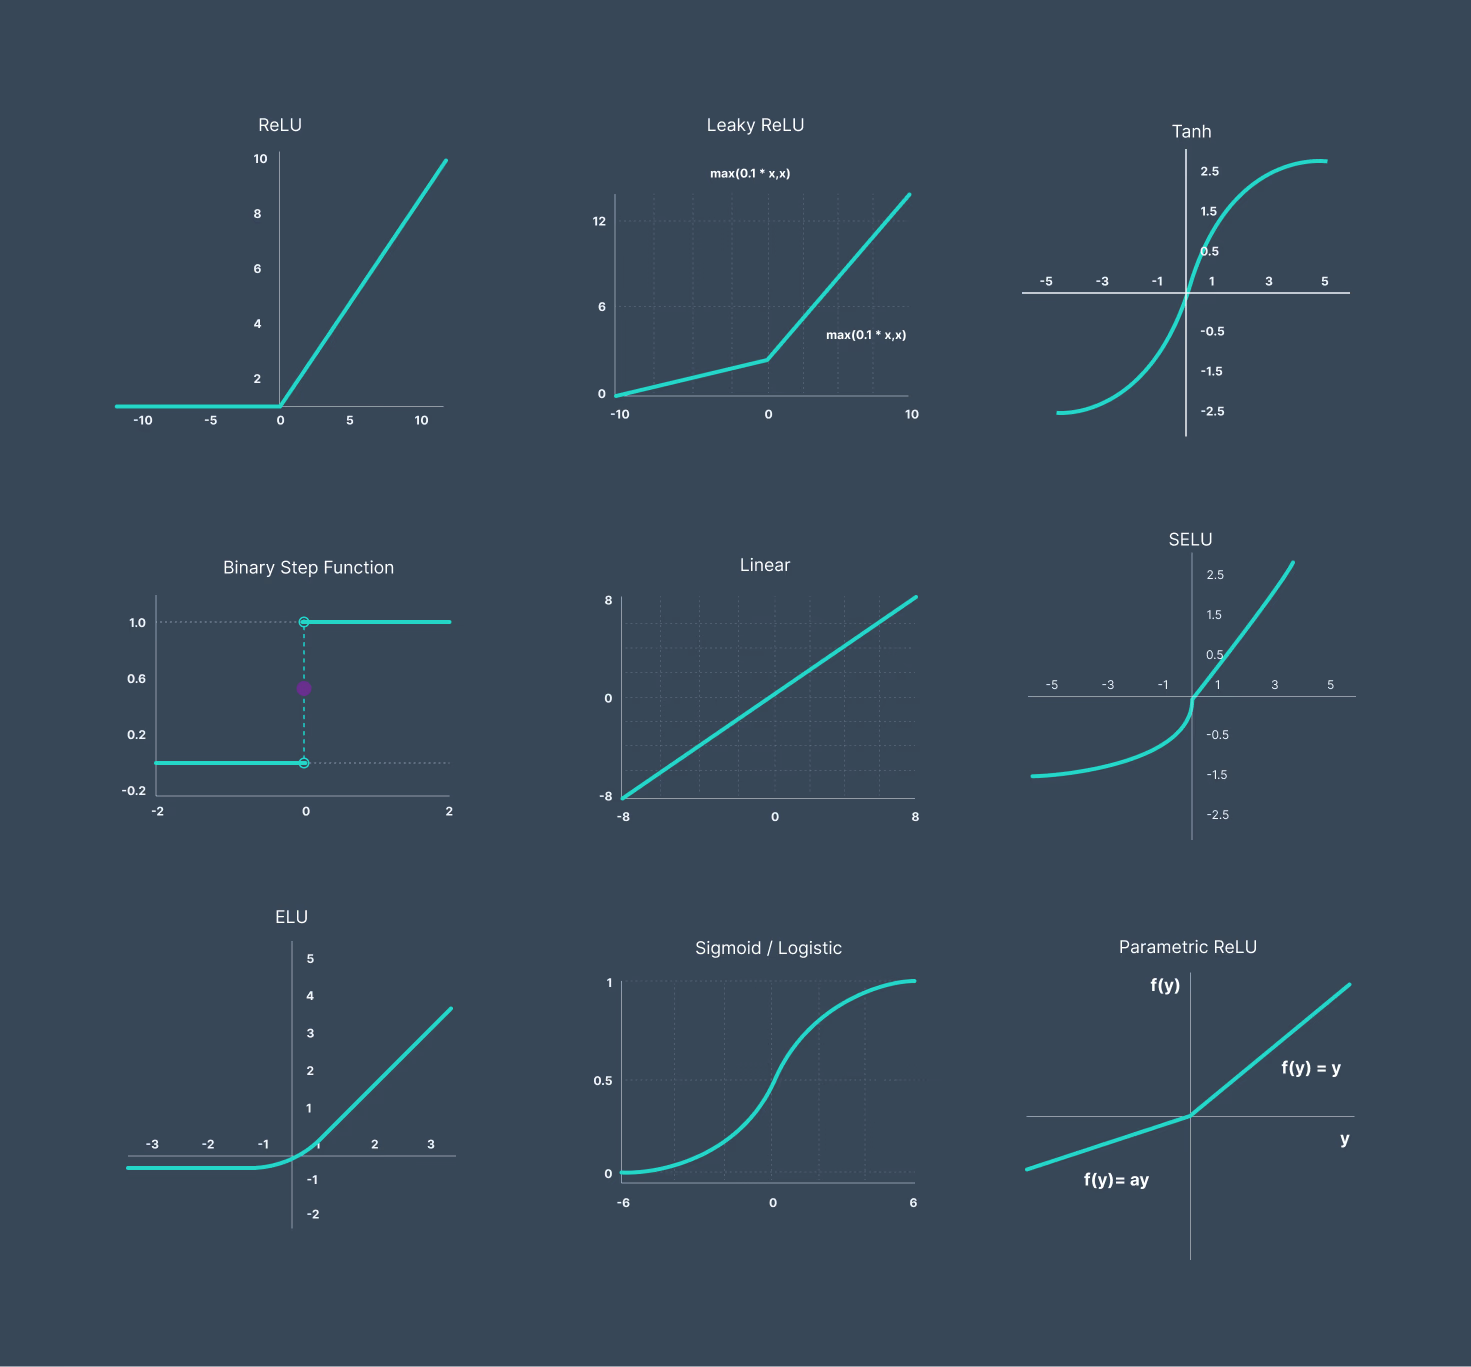


---

#### 4.2 Optymalizatory

Optymalizator określa, **w jaki sposób aktualizowane są wagi modelu** na podstawie obliczonych gradientów funkcji straty.

Do najczęściej stosowanych optymalizatorów należą:

* **SGD (Stochastic Gradient Descent)**
  Klasyczna metoda oparta bezpośrednio na gradiencie; często wymaga starannego doboru learning rate i dodatkowych technik (np. momentum).

* **[Adam](https://www.geeksforgeeks.org/deep-learning/adam-optimizer/)**
  Adaptacyjny optymalizator, który automatycznie dostosowuje learning rate dla poszczególnych parametrów; bardzo popularny ze względu na dobrą stabilność i szybkie zbieganie.


Wybór optymalizatora ma wpływ na szybkość uczenia, stabilność treningu oraz jakość znalezionego minimum funkcji straty. W praktyce wybór Adama jest zawsze dobrym wyborem i ciężko znaleźć kod który wybiera inny optymalizator. Kluczowe jednak jest wiedzieć, że tak jak większość optymalizatorów, mocno bazuje na SGD, dlatego warto być świadomym również jak działa ten klasyczny algorytm.
Z mniej znanych metod o których warto wspomnieć są [AdaGrad](https://www.geeksforgeeks.org/machine-learning/intuition-behind-adagrad-optimizer/), [RMSProp](https://medium.com/@piyushkashyap045/understanding-rmsprop-a-simple-guide-to-one-of-deep-learnings-powerful-optimizers-403baeed9922)





# KROKI DO WYKONANIA ZADANIA

W ramach zadania jesteście proszeni o wykonanie następujących kroków:

### 1. Przygotowanie danych

* Załadujcie zbiór danych i **zwizualizujcie kilka przykładowych obserwacji** (np. rozmiar obrazów, liczba kanałów, czy są kolorowe czy w skali szarości).
* Utwórzcie **DataLoadery** dla zbiorów *train*, *validation* oraz *test*, które będą zwracały dane w formacie odpowiednim dla modelu.
* Na potrzeby tego zadania **augmentacja danych nie jest wymagana**.

Done



---

### 2. Definicja modelu

* Przygotujcie klasę `ParameterizedMLP`, która będzie definiowała architekturę sieci neuronowej.
* Klasa powinna być **sparametryzowana**, tak aby możliwe było sterowanie architekturą modelu poprzez przekazywane argumenty, w szczególności:

  * liczba warstw ukrytych oraz liczba neuronów w każdej z nich,
  * użycie Batch Normalization (wystarczy flaga typu `bool`).

Done

---

### 3. Kod treningowy

* Napiszcie kod umożliwiający trening modelu, **obowiązkowo korzystając z PyTorcha lub frameworka PyTorch Lightning**.
* Kod powinien umożliwiać:

  * logowanie wartości funkcji straty oraz metryk jakości dla zbiorów *train* i *validation* w każdej epoce, Done
  * ustawienie parametru `patience`, kontrolującego działanie mechanizmu *early stopping*, Done
  * ewaluację modelu na zbiorze testowym po zakończeniu treningu, TODO
  * zapisanie **najlepszego modelu** (na podstawie wyników walidacyjnych).  TODO
* Proces treningu musi być **zdeterminowany (seedowany)**, tak aby możliwe było rzetelne porównywanie wyników pomiędzy eksperymentami. Done

---

### 4. Eksperymenty

Na przygotowanym kodzie należy przeprowadzić **kilka eksperymentów**, których celem jest zbadanie wpływu wybranych technik na proces uczenia modelu.

W szczególności powinny się pojawić następujące eksperymenty:

* **Early stopping**
  Porównanie przebiegu krzywych uczenia w przypadku:

  * treningu bez early stoppingu,
  * treningu z włączonym early stoppingiem.

* **Architektura sieci**
  Eksperymenty z różnymi architekturami sieci. Dowolność jak chcecie do tego podejść. Ja polecam dla dodania ciekawości zadania sprawdzić:
  * bardzo małą architetę
  * dużą architekturę
  * i jakąś pomiędzy którą uznamy za optymalną

* **Regularizacja**
  Porównanie uczenia:

  * z regularizacją L1 lub L2 vs. bez regularizacji,
  * z Dropoutem vs. bez Dropoutu.

* **Scheduling learning rate**
  Eksperyment pokazujący wpływ harmonogramu zmiany learning rate.
  W tym przypadku warto również **logować wartość learning rate w kolejnych epokach**.

* **Batch Normalization**
  Porównanie modelu:

  * z Batch Normalization,
  * bez Batch Normalization.

* **Optymalizator**
  Porównanie algorytmu optyalizującego wagi:
  * Adam (jako najczęściej stosowany w praktyce)
  * SGD (klasyczna metoda)

---

## UWAGI

* Nie jest wymagane przeprowadzanie rozbudowanego *grid searcha* ani badanie wszystkich możliwych kombinacji technik.
  Wystarczy podejście inkrementalne:

  * trenujecie **bazowy model** (prosta architektura, bez regularizacji, bez schedulingu learning rate, bez early stoppingu, itd),
  * następnie w kolejnych eksperymentach **zmieniacie tylko jeden czynnik naraz** (np. dodajecie early stopping, zwiększacie liczbę warstw, włączacie scheduler itp.) i obserwujecie jego wpływ na wyniki.

* Z tego powodu **wszystkie eksperymenty powinny być wykonywane na tym samym seedzie oraz tym samym podziale danych** (ten sam split train/val/test), aby porównania były miarodajne.

* Warto zadbać o to, aby kod był **czytelny, modularny i dobrze zorganizowany**.
  W kolejnych zadaniach będziecie pracować z modelami konwolucyjnymi — dobrze napisany kod treningowy będzie można w dużej mierze ponownie wykorzystać.
* W tym zadaniu nie jest wymagane systematyczne porównywanie wszystkich funkcji aktywacji (chodź nie jest zakazane), należy natomiast wybrać jedną i uwzględnić ją w implementacji modelu.


#1. Wczytanie danych i ich podział



In [ ]:
from torchvision import datasets
from google.colab import drive
from pathlib import Path
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

In [ ]:


drive.mount('/content/drive')
base_path = Path('/content/drive/MyDrive/FashionMINST')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


trainset = datasets.FashionMNIST(
    root=base_path,
    train=True,
    download=True,
    transform=transform
)

testset = datasets.FashionMNIST(
    root=base_path,
    train=False,
    download=True,
    transform=transform
)


Mounted at /content/drive


In [ ]:
trainset[0][0].shape

torch.Size([1, 28, 28])

Mamy rozmiar 28x28 pikseli

In [ ]:
trainset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
trainset.targets.bincount()

tensor([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000])

Jak widać mamy po tyle samo próbek dla każdej kategorii

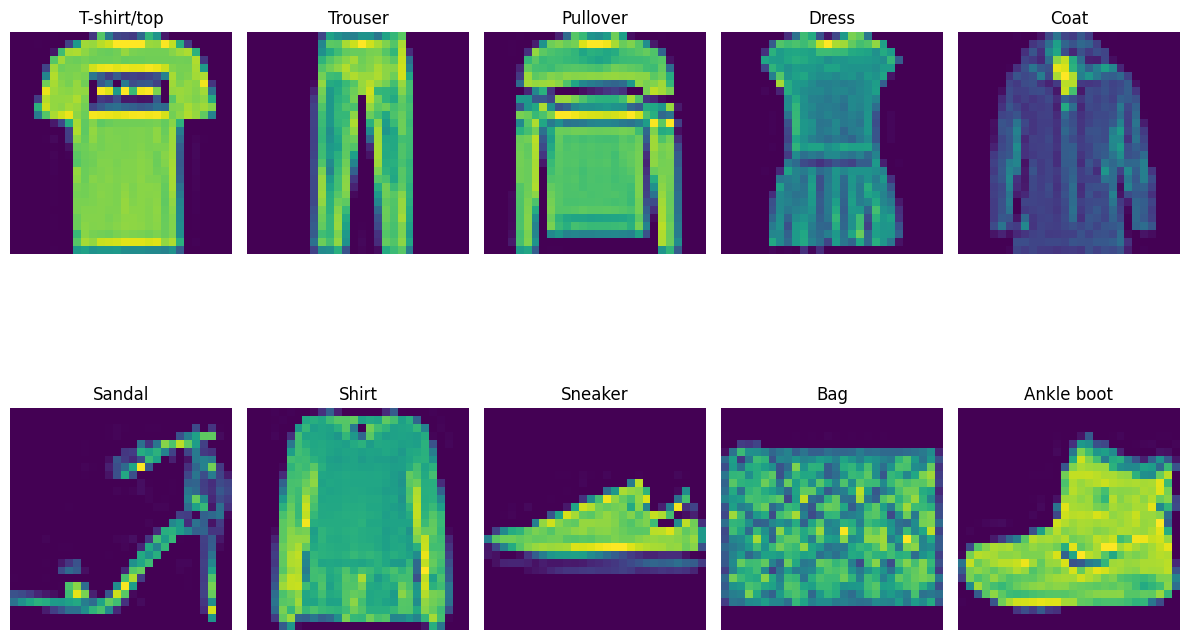

In [ ]:
classes = trainset.classes
plt.figure(figsize=(12, 12))

for i, class_name in enumerate(classes):
    idx = (np.array(trainset.targets) == i).nonzero()[0][0]

    img, label = trainset[idx]

    plt.subplot(len(classes) // 5 + 1, 5, i + 1)

    img = img.permute(1, 2, 0)

    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
customSEED=42

import torch
from torch.utils.data import DataLoader, random_split



np.random.seed(customSEED)
torch.manual_seed(customSEED)
torch.cuda.manual_seed_all(customSEED)

g = torch.Generator()
g.manual_seed(customSEED)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = random_split(trainset, [train_size, val_size], generator=g)


In [ ]:
class ParametrizedMLP(nn.Module):
  def __init__(self, BatchNormalization: bool, hiddenLayers, outputSize, inputDim, dropout=0.0):
    super().__init__()

    layers=[]

    for hiddenDim in hiddenLayers:
      layers.append(nn.Linear(inputDim, hiddenDim))
      if BatchNormalization:
        layers.append(nn.BatchNorm1d(hiddenDim))

      layers.append(nn.ReLU())

      if dropout!=0:
        layers.append(nn.Dropout(dropout))
      inputDim=hiddenDim

    layers.append(nn.Linear(inputDim, outputSize))
    self.model=nn.Sequential(*layers)
  def forward(self,x):
    x = x.view(x.size(0), -1)

    return self.model(x)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

class TrainerTorch:
    def __init__(self,
                 model,
                 n_epochs=20,
                 batch_size=256,
                 lr=0.01,
                 patience=3,
                 optimizer: str = "SGD",
                 use_early_stopping: bool = False,
                 generator=None,
                 regularization: bool = False,
                 lambda_reg=0.01,
                 cosine_learning_rate: bool = False):

        self.model = model
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.optimizer_name = optimizer
        self.use_early_stopping = use_early_stopping
        self.generator = generator
        self.regularization = regularization
        self.cosine_learning_rate = cosine_learning_rate
        self.lambda_reg = lambda_reg

        self.lr_history = defaultdict(list)

        self.history = defaultdict(list)
        self.best_val_loss = float('inf')
        self.early_stop_counter = 0

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()

    def train(self, train_dataset, val_dataset):

        train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            generator=self.generator,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        print(f"Rozpoczynam trening na: {self.device}")

        weight_decay = self.lambda_reg if self.regularization else 0.0

        if self.optimizer_name == "SGD":
            optimizer = torch.optim.SGD(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)
        else:
            optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)

        if self.cosine_learning_rate:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.n_epochs)

        for epoch in range(self.n_epochs):
            self.model.train()

            epoch_loss = 0.0
            epoch_correct = 0
            total_samples = 0 #zeby nie leciec przez caly zbior potem w evaluate (20 epok zajelo 8min)

            for X, y in train_loader:
                X, y = X.to(self.device), y.to(self.device)


                optimizer.zero_grad()
                output = self.model(X)
                loss = self.criterion(output, y)

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item() * X.size(0)
                predicted = output.argmax(dim=1)
                epoch_correct += (predicted == y).sum().item()
                total_samples += y.size(0)

            if self.cosine_learning_rate:
                scheduler.step()
                print(scheduler.get_lr())
                self.lr_history['lr'].append(scheduler.get_last_lr())

            train_l = epoch_loss / total_samples
            train_acc = epoch_correct / total_samples

            self.model.eval()
            with torch.no_grad():
                val_l, val_acc, _ = self.evaluate(val_loader)

                self.history['train_loss'].append(train_l)
                self.history['val_loss'].append(val_l)
                self.history['train_acc'].append(train_acc)
                self.history['val_acc'].append(val_acc)

                print(f"Epoch {epoch+1}/{self.n_epochs} | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_acc:.4f}")

                if val_l < self.best_val_loss:
                    self.best_val_loss = val_l
                    self.early_stop_counter = 0
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': self.model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': val_l,
                    }, 'checkpoint.pt')
                else:
                    self.early_stop_counter += 1

                if self.use_early_stopping and self.early_stop_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        self.plot_history()
        checkpoint = torch.load('checkpoint.pt', weights_only=False)
        self.model.load_state_dict(checkpoint['model_state_dict'])

    def evaluate(self, loader):
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        all_preds = []

        self.model.eval() # Dobra praktyka: upewnij się, że model jest w trybie eval
        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)

                outputs = self.model(X)
                loss = self.criterion(outputs, y)

                total_loss += loss.item() * X.size(0)

                predicted = outputs.argmax(dim=1)
                total_correct += (predicted == y).sum().item()

                total_samples += y.size(0)
                all_preds.append(outputs)

        avg_loss = total_loss / total_samples
        avg_acc = total_correct / total_samples
        full_preds = torch.cat(all_preds) if all_preds else None

        return avg_loss, avg_acc, full_preds


    def predict(self, x_test):
        test_loader = DataLoader(
            x_test,
            batch_size=self.batch_size,
            shuffle=False,
            generator=self.generator
        )
        self.model.eval()
        with torch.no_grad():
          loss, acc, A = self.evaluate(test_loader)
          print("Loss: "+str(loss))
          print("Acc: "+str(acc))
          return A


    def plot_history(self):
      epochs = range(1, len(self.history['train_loss']) + 1)

      plt.figure(figsize=(16, 5))

      plt.subplot(1, 2, 1)
      plt.plot(epochs, self.history['train_loss'], label='Train Loss')
      plt.plot(epochs, self.history['val_loss'], label='Val Loss')
      plt.title('Training and Validation Loss')
      plt.xlabel('Epochs')
      plt.ylabel('Loss')
      plt.legend()
      plt.grid(True)

      plt.subplot(1, 2, 2)
      plt.plot(epochs, self.history['train_acc'], label='Train Acc')
      plt.plot(epochs, self.history['val_acc'], label='Val Acc')
      plt.title('Training and Validation Accuracy')
      plt.xlabel('Epochs')
      plt.ylabel('Accuracy')
      plt.legend()
      plt.grid(True)

      plt.tight_layout()
      plt.show()

Ściąga testów do zrobienia

* **Early stopping**
  Porównanie przebiegu krzywych uczenia w przypadku:

  * treningu bez early stoppingu,
  * treningu z włączonym early stoppingiem.

* **Architektura sieci**
  Eksperymenty z różnymi architekturami sieci. Dowolność jak chcecie do tego podejść. Ja polecam dla dodania ciekawości zadania sprawdzić:
  * bardzo małą architetę
  * dużą architekturę
  * i jakąś pomiędzy którą uznamy za optymalną

* **Regularizacja**
  Porównanie uczenia:

  * z regularizacją L1 lub L2 vs. bez regularizacji,
  * z Dropoutem vs. bez Dropoutu.

* **Scheduling learning rate**
  Eksperyment pokazujący wpływ harmonogramu zmiany learning rate.
  W tym przypadku warto również **logować wartość learning rate w kolejnych epokach**.

* **Batch Normalization**
  Porównanie modelu:

  * z Batch Normalization,
  * bez Batch Normalization.

* **Optymalizator**
  Porównanie algorytmu optyalizującego wagi:
  * Adam (jako najczęściej stosowany w praktyce)
  * SGD (klasyczna metoda)

**TESTY**

* **Early stopping**
  Porównanie przebiegu krzywych uczenia w przypadku:

  * treningu bez early stoppingu,
  * treningu z włączonym early stoppingiem.


Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.9316 | Val Loss: 1.3980 | Val Acc: 0.6119
Epoch 2/20 | Train Loss: 1.0830 | Val Loss: 0.8883 | Val Acc: 0.7127
Epoch 3/20 | Train Loss: 0.7886 | Val Loss: 0.7308 | Val Acc: 0.7433
Epoch 4/20 | Train Loss: 0.6809 | Val Loss: 0.6614 | Val Acc: 0.7608
Epoch 5/20 | Train Loss: 0.6264 | Val Loss: 0.6186 | Val Acc: 0.7714
Epoch 6/20 | Train Loss: 0.5905 | Val Loss: 0.5899 | Val Acc: 0.7853
Epoch 7/20 | Train Loss: 0.5645 | Val Loss: 0.5648 | Val Acc: 0.7999
Epoch 8/20 | Train Loss: 0.5432 | Val Loss: 0.5459 | Val Acc: 0.8104
Epoch 9/20 | Train Loss: 0.5257 | Val Loss: 0.5321 | Val Acc: 0.8143
Epoch 10/20 | Train Loss: 0.5112 | Val Loss: 0.5199 | Val Acc: 0.8171
Epoch 11/20 | Train Loss: 0.4983 | Val Loss: 0.5104 | Val Acc: 0.8217
Epoch 12/20 | Train Loss: 0.4871 | Val Loss: 0.4954 | Val Acc: 0.8270
Epoch 13/20 | Train Loss: 0.4771 | Val Loss: 0.4866 | Val Acc: 0.8275
Epoch 14/20 | Train Loss: 0.4682 | Val Loss: 0.4782 | Val Acc: 0.8315


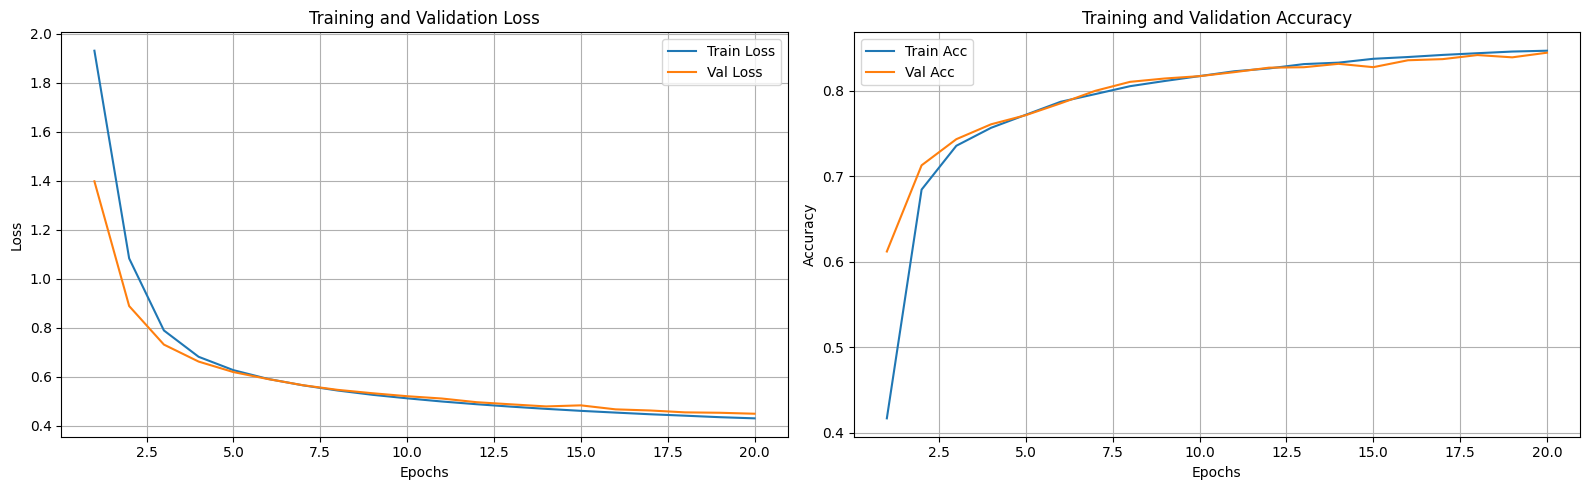

Test:
Loss: 0.46577285933494567
Acc: 0.8328


tensor([[ -3.5802,  -7.0875,  -3.1268,  ...,   7.4388,   2.8751,   7.7104],
        [  2.3202,  -1.3700,  10.0969,  ..., -13.6237,   1.6006, -10.6907],
        [  3.9479,  12.8312,  -0.0534,  ...,  -7.2377,  -3.6734, -10.6154],
        ...,
        [  3.0607,  -5.4819,  -0.5106,  ...,  -3.3755,   6.1578,  -5.4748],
        [  0.8568,   9.7155,  -1.2061,  ...,  -4.6074,  -4.0960,  -6.4701],
        [ -2.4480,  -3.3874,  -1.7778,  ...,   4.0709,   2.1027,   1.1246]],
       device='cuda:0')

In [ ]:
MLP = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
Trainer = TrainerTorch(model=MLP, generator=g)
Trainer.train(train_subset, val_subset)
print("Test:")
Trainer.predict(testset)




Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.9520 | Val Loss: 1.4345 | Val Acc: 0.5709
Epoch 2/20 | Train Loss: 1.0863 | Val Loss: 0.8788 | Val Acc: 0.7151
Epoch 3/20 | Train Loss: 0.7812 | Val Loss: 0.7361 | Val Acc: 0.7392
Epoch 4/20 | Train Loss: 0.6817 | Val Loss: 0.6661 | Val Acc: 0.7604
Epoch 5/20 | Train Loss: 0.6272 | Val Loss: 0.6215 | Val Acc: 0.7774
Epoch 6/20 | Train Loss: 0.5895 | Val Loss: 0.5884 | Val Acc: 0.7912
Epoch 7/20 | Train Loss: 0.5602 | Val Loss: 0.5679 | Val Acc: 0.7998
Epoch 8/20 | Train Loss: 0.5381 | Val Loss: 0.5468 | Val Acc: 0.8081
Epoch 9/20 | Train Loss: 0.5194 | Val Loss: 0.5343 | Val Acc: 0.8147
Epoch 10/20 | Train Loss: 0.5049 | Val Loss: 0.5212 | Val Acc: 0.8192
Epoch 11/20 | Train Loss: 0.4933 | Val Loss: 0.5048 | Val Acc: 0.8210
Epoch 12/20 | Train Loss: 0.4833 | Val Loss: 0.5072 | Val Acc: 0.8214
Epoch 13/20 | Train Loss: 0.4736 | Val Loss: 0.4879 | Val Acc: 0.8290
Epoch 14/20 | Train Loss: 0.4664 | Val Loss: 0.4807 | Val Acc: 0.8337


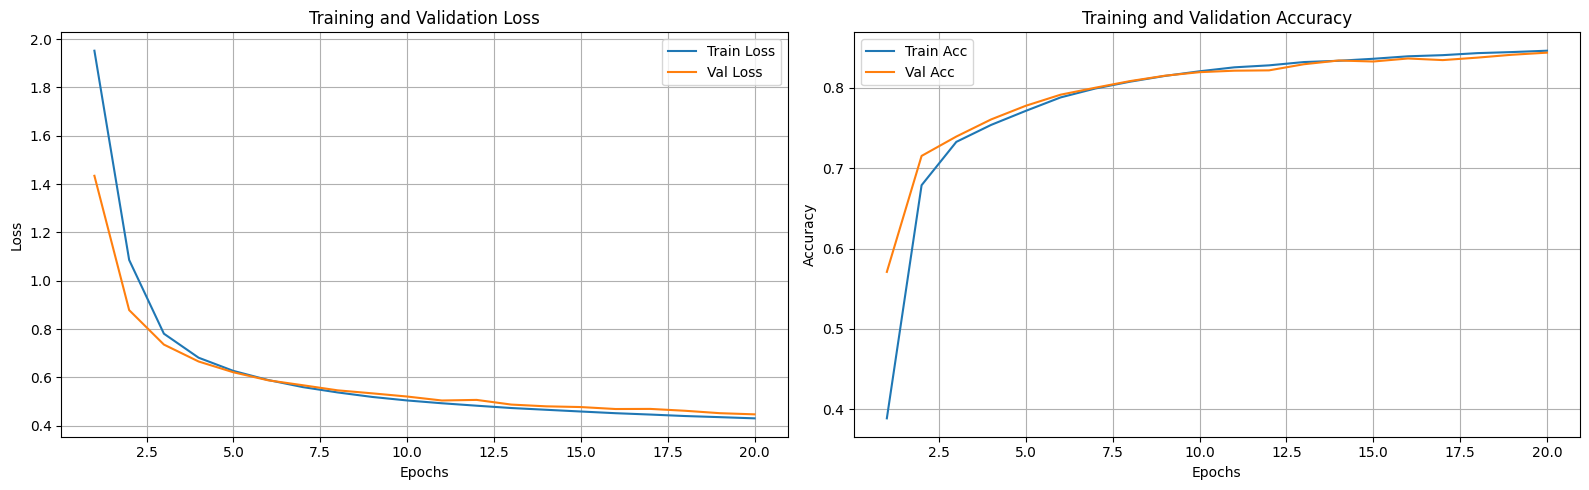

Test:
Loss: 0.46692864665985107
Acc: 0.8326


tensor([[ -5.2401,  -8.2480,  -3.6780,  ...,   7.2572,   4.1115,   8.2324],
        [  1.1914,  -1.2648,   8.9615,  ..., -10.9739,   1.5772,  -7.3114],
        [  2.6628,  14.4059,   1.7321,  ...,  -1.5529,  -2.5031, -11.7197],
        ...,
        [  3.1710,  -5.9804,  -0.9094,  ...,  -4.4963,   6.6280,  -3.7717],
        [  0.3340,  11.0571,   0.3971,  ...,  -0.2660,  -2.2208,  -8.2314],
        [ -3.1969,  -3.4716,  -1.0996,  ...,   3.4187,   2.4912,   0.7120]],
       device='cuda:0')

In [ ]:
MLP_E=ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerEarlyStop = TrainerTorch(model=MLP_E, use_early_stopping=True, generator=g)
TrainerEarlyStop.train(train_subset, val_subset)
print("Test:")
TrainerEarlyStop.predict(testset)


Jak widać w moim przypadku early stopping nie zadziałał, bo według modelu val_loss ciągle szło trochę w dół, powinienem chyba dodać, żeby się zatrzymywał przy +/- 0.05 bo to bez sensu i szkoda API na tą ptorzebe

* **Architektura sieci**
  Eksperymenty z różnymi architekturami sieci. Dowolność jak chcecie do tego podejść. Ja polecam dla dodania ciekawości zadania sprawdzić:
  * bardzo małą architetę
  * dużą architekturę
  * i jakąś pomiędzy którą uznamy za optymalną


In [ ]:
MLP_s = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[50,50],outputSize=10,inputDim=784)
MLP_m = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
MLP_b = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[256,256],outputSize=10,inputDim=784)

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.9408 | Val Loss: 1.3889 | Val Acc: 0.6258
Epoch 2/20 | Train Loss: 1.0512 | Val Loss: 0.8676 | Val Acc: 0.7078
Epoch 3/20 | Train Loss: 0.7729 | Val Loss: 0.7311 | Val Acc: 0.7392
Epoch 4/20 | Train Loss: 0.6785 | Val Loss: 0.6651 | Val Acc: 0.7588
Epoch 5/20 | Train Loss: 0.6258 | Val Loss: 0.6268 | Val Acc: 0.7729
Epoch 6/20 | Train Loss: 0.5899 | Val Loss: 0.5930 | Val Acc: 0.7903
Epoch 7/20 | Train Loss: 0.5629 | Val Loss: 0.5673 | Val Acc: 0.8026
Epoch 8/20 | Train Loss: 0.5419 | Val Loss: 0.5514 | Val Acc: 0.8030
Epoch 9/20 | Train Loss: 0.5245 | Val Loss: 0.5354 | Val Acc: 0.8126
Epoch 10/20 | Train Loss: 0.5107 | Val Loss: 0.5253 | Val Acc: 0.8139
Epoch 11/20 | Train Loss: 0.4985 | Val Loss: 0.5134 | Val Acc: 0.8217
Epoch 12/20 | Train Loss: 0.4886 | Val Loss: 0.5021 | Val Acc: 0.8242
Epoch 13/20 | Train Loss: 0.4800 | Val Loss: 0.4944 | Val Acc: 0.8261
Epoch 14/20 | Train Loss: 0.4722 | Val Loss: 0.4903 | Val Acc: 0.8281


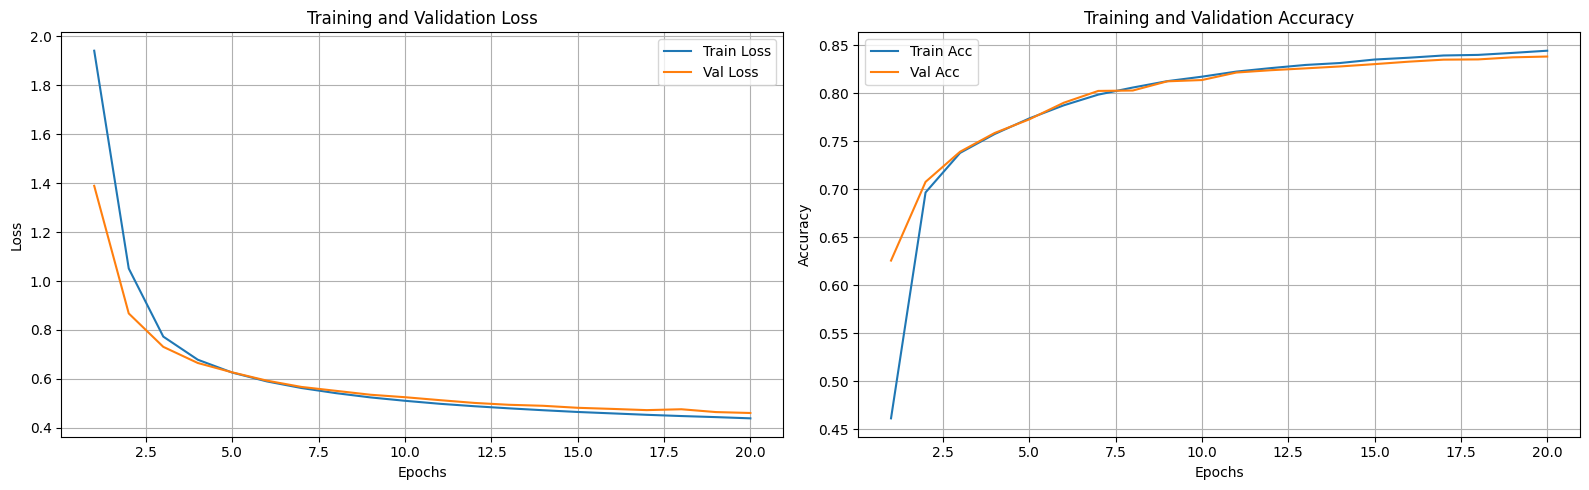

Test:
Loss: 0.47899076654911044
Acc: 0.8298


tensor([[ -4.8102,  -4.7243,  -3.9850,  ...,   5.7460,   2.5376,   6.3693],
        [  0.8067,  -3.2663,   8.2261,  ..., -13.3251,   0.3614,  -6.5757],
        [  0.9170,  12.5241,   0.6854,  ...,  -3.4843,  -5.6681,  -4.4811],
        ...,
        [  2.5747,  -5.8610,  -0.6575,  ...,  -3.0676,   5.7554,  -6.1956],
        [ -1.3685,   9.2465,  -0.6448,  ...,  -0.4289,  -5.2220,  -1.1639],
        [ -3.8939,  -3.1913,  -2.1954,  ...,   3.6274,   0.8158,   0.4432]],
       device='cuda:0')

In [ ]:
TrainerSize = TrainerTorch(model=MLP_s, use_early_stopping=False, generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.8726 | Val Loss: 1.3266 | Val Acc: 0.6254
Epoch 2/20 | Train Loss: 1.0425 | Val Loss: 0.8720 | Val Acc: 0.7239
Epoch 3/20 | Train Loss: 0.7779 | Val Loss: 0.7311 | Val Acc: 0.7420
Epoch 4/20 | Train Loss: 0.6803 | Val Loss: 0.6648 | Val Acc: 0.7642
Epoch 5/20 | Train Loss: 0.6275 | Val Loss: 0.6219 | Val Acc: 0.7791
Epoch 6/20 | Train Loss: 0.5912 | Val Loss: 0.5936 | Val Acc: 0.7891
Epoch 7/20 | Train Loss: 0.5633 | Val Loss: 0.5673 | Val Acc: 0.8017
Epoch 8/20 | Train Loss: 0.5412 | Val Loss: 0.5468 | Val Acc: 0.8077
Epoch 9/20 | Train Loss: 0.5237 | Val Loss: 0.5354 | Val Acc: 0.8178
Epoch 10/20 | Train Loss: 0.5091 | Val Loss: 0.5191 | Val Acc: 0.8212
Epoch 11/20 | Train Loss: 0.4964 | Val Loss: 0.5093 | Val Acc: 0.8253
Epoch 12/20 | Train Loss: 0.4855 | Val Loss: 0.5017 | Val Acc: 0.8262
Epoch 13/20 | Train Loss: 0.4763 | Val Loss: 0.4916 | Val Acc: 0.8319
Epoch 14/20 | Train Loss: 0.4682 | Val Loss: 0.4822 | Val Acc: 0.8323


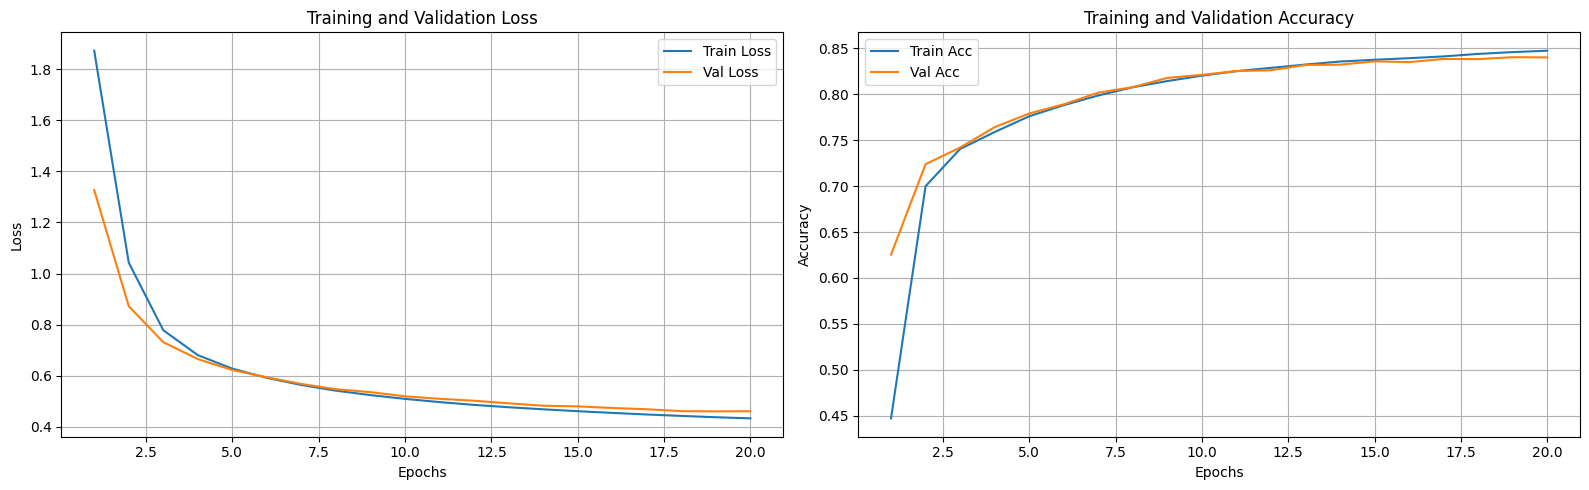

Test:
Loss: 0.47778807950019836
Acc: 0.8325


tensor([[ -3.4416,  -5.9520,  -4.4240,  ...,   7.8944,   4.0224,   8.1224],
        [  1.5966,  -0.9517,   9.3606,  ..., -11.1545,   1.6230,  -8.4553],
        [  2.6512,  13.8099,   0.7295,  ...,  -3.3398,  -4.1856,  -5.9207],
        ...,
        [  3.2622,  -5.8670,  -0.5494,  ...,  -2.4224,   7.0195,  -4.2191],
        [  0.8901,  10.4000,  -0.4484,  ...,  -0.5699,  -3.1845,  -3.1064],
        [ -2.3364,  -3.5225,  -1.3927,  ...,   4.5060,   2.6109,   1.5314]],
       device='cuda:0')

In [ ]:
TrainerSize = TrainerTorch(model=MLP_m, use_early_stopping=False, generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.7929 | Val Loss: 1.2050 | Val Acc: 0.6781
Epoch 2/20 | Train Loss: 0.9483 | Val Loss: 0.8074 | Val Acc: 0.7305
Epoch 3/20 | Train Loss: 0.7311 | Val Loss: 0.6953 | Val Acc: 0.7535
Epoch 4/20 | Train Loss: 0.6511 | Val Loss: 0.6379 | Val Acc: 0.7704
Epoch 5/20 | Train Loss: 0.6053 | Val Loss: 0.6000 | Val Acc: 0.7847
Epoch 6/20 | Train Loss: 0.5721 | Val Loss: 0.5776 | Val Acc: 0.7944
Epoch 7/20 | Train Loss: 0.5467 | Val Loss: 0.5510 | Val Acc: 0.8079
Epoch 8/20 | Train Loss: 0.5261 | Val Loss: 0.5320 | Val Acc: 0.8153
Epoch 9/20 | Train Loss: 0.5098 | Val Loss: 0.5189 | Val Acc: 0.8171
Epoch 10/20 | Train Loss: 0.4960 | Val Loss: 0.5066 | Val Acc: 0.8253
Epoch 11/20 | Train Loss: 0.4841 | Val Loss: 0.4925 | Val Acc: 0.8307
Epoch 12/20 | Train Loss: 0.4736 | Val Loss: 0.4952 | Val Acc: 0.8240
Epoch 13/20 | Train Loss: 0.4656 | Val Loss: 0.4800 | Val Acc: 0.8354
Epoch 14/20 | Train Loss: 0.4577 | Val Loss: 0.4737 | Val Acc: 0.8347


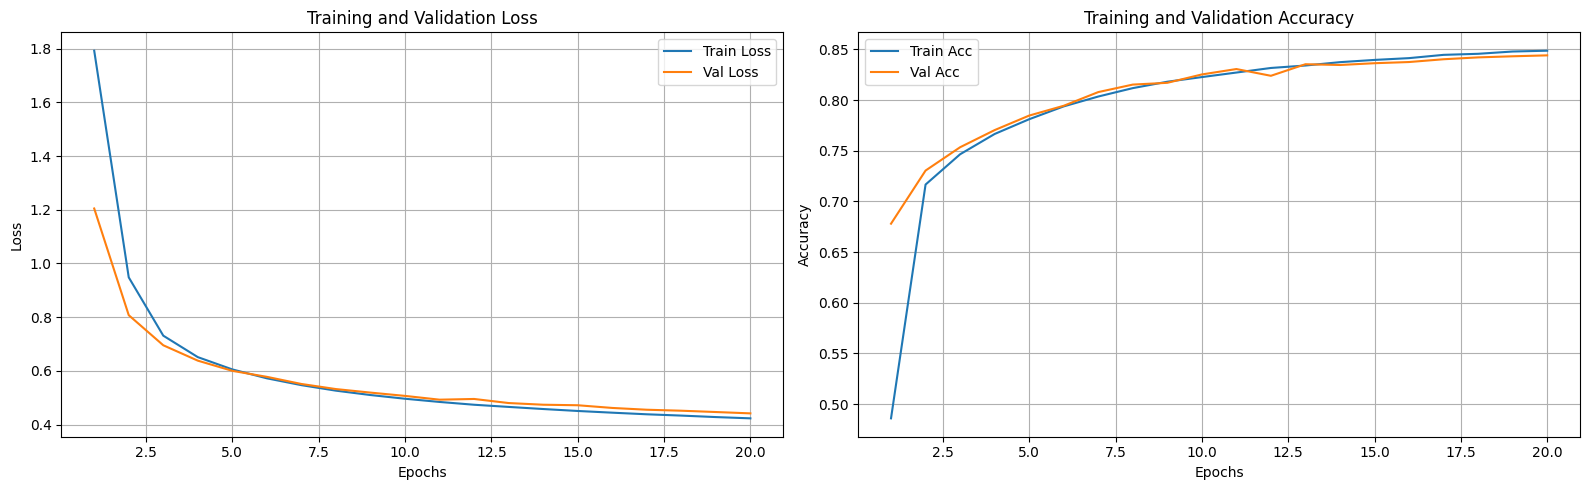

Test:
Loss: 0.4595292829990387
Acc: 0.8328


tensor([[ -4.3234,  -5.9533,  -3.9264,  ...,   7.0909,   3.6824,   8.1912],
        [  1.4562,  -0.7181,   8.8720,  ..., -11.1499,   0.8369,  -7.5623],
        [  2.4293,  12.3971,   1.4645,  ...,  -1.0161,  -2.2181,  -7.4416],
        ...,
        [  3.9857,  -5.2435,   0.0776,  ...,  -2.5066,   7.0828,  -4.4347],
        [  0.0537,  10.0215,  -0.0206,  ...,   0.6035,  -3.1305,  -3.5756],
        [ -2.5416,  -3.2947,  -1.2101,  ...,   3.7120,   2.3147,   1.1787]],
       device='cuda:0')

In [ ]:
TrainerSize = TrainerTorch(model=MLP_b, use_early_stopping=False, generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Co ciekawe w tym przypadku modele sobie poradziły praktycznie identyczne, może się wkradł jakiś błąd (?)

* **Regularizacja**
  Porównanie uczenia:

  * z regularizacją L1 lub L2 vs. bez regularizacji,

Bez L1:

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.8922 | Val Loss: 1.3397 | Val Acc: 0.6403
Epoch 2/20 | Train Loss: 1.0364 | Val Loss: 0.8583 | Val Acc: 0.7192
Epoch 3/20 | Train Loss: 0.7692 | Val Loss: 0.7257 | Val Acc: 0.7433
Epoch 4/20 | Train Loss: 0.6764 | Val Loss: 0.6637 | Val Acc: 0.7593
Epoch 5/20 | Train Loss: 0.6261 | Val Loss: 0.6207 | Val Acc: 0.7750
Epoch 6/20 | Train Loss: 0.5913 | Val Loss: 0.5912 | Val Acc: 0.7867
Epoch 7/20 | Train Loss: 0.5642 | Val Loss: 0.5655 | Val Acc: 0.8000
Epoch 8/20 | Train Loss: 0.5425 | Val Loss: 0.5464 | Val Acc: 0.8067
Epoch 9/20 | Train Loss: 0.5249 | Val Loss: 0.5306 | Val Acc: 0.8111
Epoch 10/20 | Train Loss: 0.5096 | Val Loss: 0.5163 | Val Acc: 0.8186
Epoch 11/20 | Train Loss: 0.4963 | Val Loss: 0.5046 | Val Acc: 0.8244
Epoch 12/20 | Train Loss: 0.4847 | Val Loss: 0.4993 | Val Acc: 0.8264
Epoch 13/20 | Train Loss: 0.4750 | Val Loss: 0.4890 | Val Acc: 0.8296
Epoch 14/20 | Train Loss: 0.4660 | Val Loss: 0.4804 | Val Acc: 0.8313


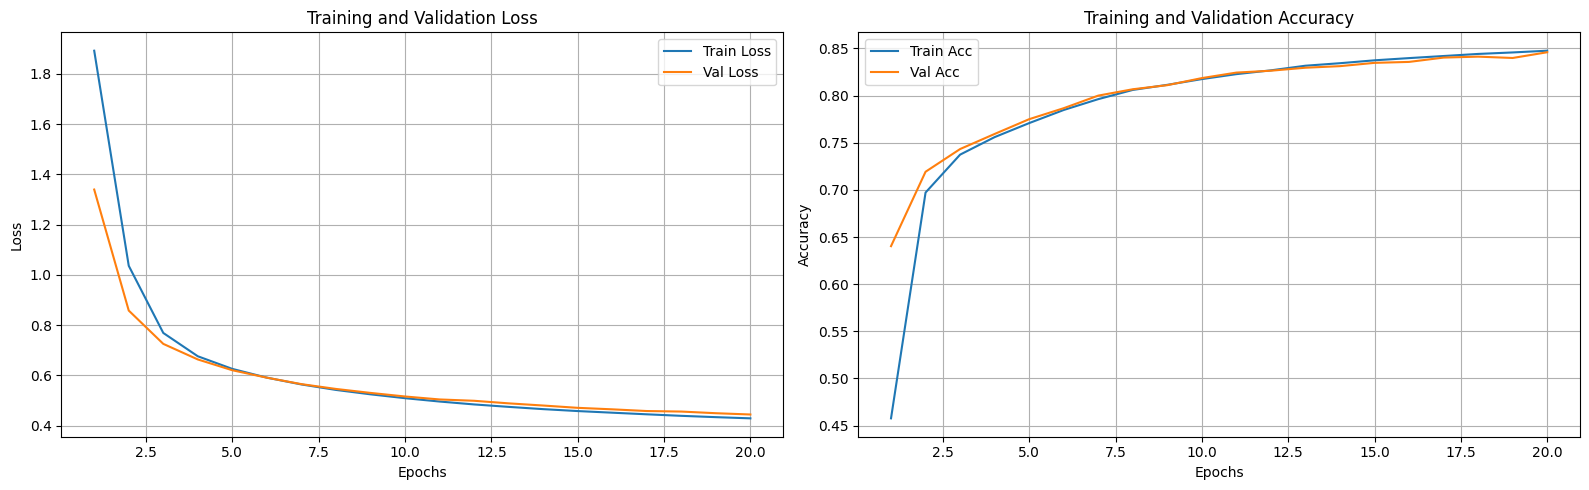

Test:
Loss: 0.4674862096786499
Acc: 0.8319


tensor([[-3.7539e+00, -6.5447e+00, -3.3023e+00,  ...,  7.0737e+00,
          2.9882e+00,  7.5511e+00],
        [ 9.1483e-01, -1.2111e+00,  8.4450e+00,  ..., -9.6419e+00,
          1.5634e-01, -6.0680e+00],
        [ 2.8389e+00,  1.3768e+01,  8.7482e-01,  ..., -3.5328e+00,
         -3.7514e+00, -8.0001e+00],
        ...,
        [ 2.9386e+00, -5.1252e+00, -1.2717e+00,  ..., -4.2379e+00,
          6.5414e+00, -4.4443e+00],
        [-9.1219e-03,  1.0556e+01,  3.3667e-01,  ..., -1.3931e+00,
         -4.1952e+00, -4.2622e+00],
        [-2.5379e+00, -3.0290e+00, -1.3520e+00,  ...,  4.0488e+00,
          1.9420e+00,  9.0044e-01]], device='cuda:0')

In [ ]:
MLP_no_L1 = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerSize = TrainerTorch(model=MLP_no_L1,generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Z L2:

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.8888 | Val Loss: 1.4142 | Val Acc: 0.5942
Epoch 2/20 | Train Loss: 1.1159 | Val Loss: 0.9143 | Val Acc: 0.7221
Epoch 3/20 | Train Loss: 0.8077 | Val Loss: 0.7482 | Val Acc: 0.7408
Epoch 4/20 | Train Loss: 0.6999 | Val Loss: 0.6813 | Val Acc: 0.7568
Epoch 5/20 | Train Loss: 0.6491 | Val Loss: 0.6440 | Val Acc: 0.7638
Epoch 6/20 | Train Loss: 0.6159 | Val Loss: 0.6139 | Val Acc: 0.7788
Epoch 7/20 | Train Loss: 0.5915 | Val Loss: 0.5922 | Val Acc: 0.7907
Epoch 8/20 | Train Loss: 0.5725 | Val Loss: 0.5771 | Val Acc: 0.7963
Epoch 9/20 | Train Loss: 0.5563 | Val Loss: 0.5623 | Val Acc: 0.8027
Epoch 10/20 | Train Loss: 0.5424 | Val Loss: 0.5495 | Val Acc: 0.8096
Epoch 11/20 | Train Loss: 0.5303 | Val Loss: 0.5392 | Val Acc: 0.8133
Epoch 12/20 | Train Loss: 0.5198 | Val Loss: 0.5278 | Val Acc: 0.8150
Epoch 13/20 | Train Loss: 0.5106 | Val Loss: 0.5208 | Val Acc: 0.8198
Epoch 14/20 | Train Loss: 0.5024 | Val Loss: 0.5171 | Val Acc: 0.8205


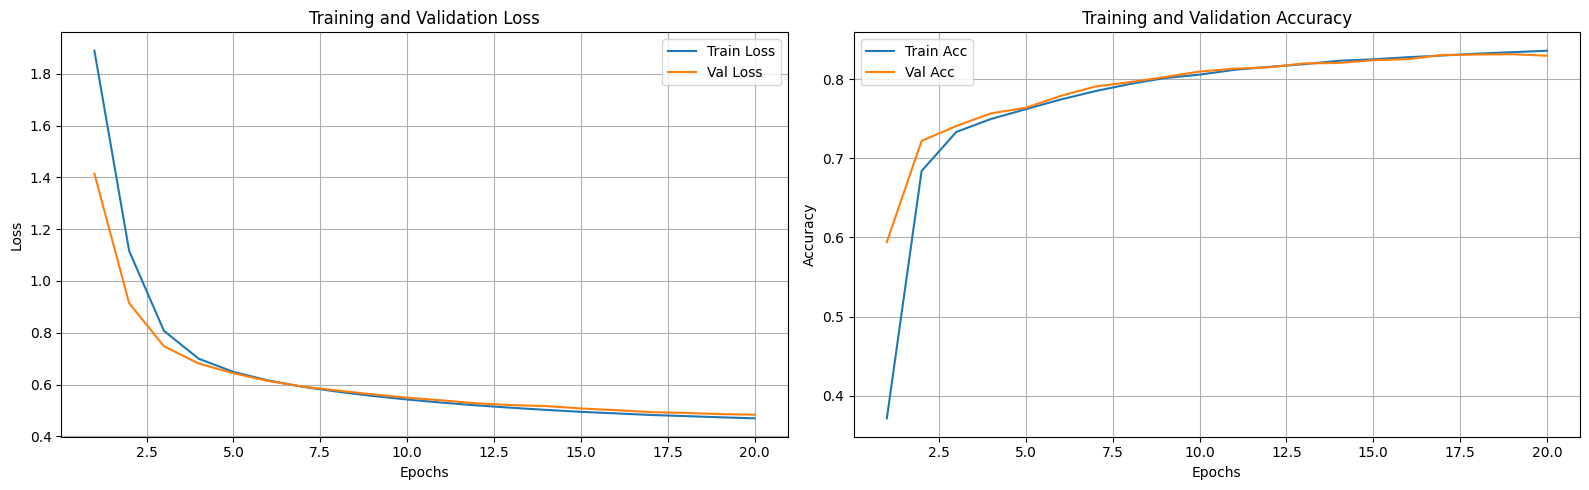

Test:
Loss: 0.5014550549983978
Acc: 0.8194


tensor([[ -4.5070,  -3.6075,  -3.5346,  ...,   5.6384,   2.6137,   6.1182],
        [  1.4093,  -0.3972,   7.6651,  ..., -10.5405,   0.7757,  -6.2396],
        [  2.2581,  11.1605,   1.5454,  ...,  -2.4977,  -4.3221,  -3.2876],
        ...,
        [  2.3971,  -4.3133,  -0.6674,  ...,  -0.7683,   5.1440,  -3.0525],
        [  0.3090,   8.8528,   0.0376,  ...,  -0.5629,  -4.1745,  -1.2286],
        [ -2.6453,  -2.5317,  -1.5722,  ...,   3.4337,   1.7196,   1.3151]],
       device='cuda:0')

In [ ]:
MLP_L1 = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerSize = TrainerTorch(model=MLP_L1,generator=g, regularization=True)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

W tym przypadku regularyzacja L1 przekszodzła lekko modelowi

  * z Dropoutem vs. bez Dropoutu.


Bez:

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.7647 | Val Loss: 1.2135 | Val Acc: 0.6518
Epoch 2/20 | Train Loss: 0.9725 | Val Loss: 0.8336 | Val Acc: 0.7232
Epoch 3/20 | Train Loss: 0.7544 | Val Loss: 0.7163 | Val Acc: 0.7472
Epoch 4/20 | Train Loss: 0.6677 | Val Loss: 0.6521 | Val Acc: 0.7605
Epoch 5/20 | Train Loss: 0.6178 | Val Loss: 0.6146 | Val Acc: 0.7799
Epoch 6/20 | Train Loss: 0.5820 | Val Loss: 0.5800 | Val Acc: 0.7962
Epoch 7/20 | Train Loss: 0.5544 | Val Loss: 0.5572 | Val Acc: 0.8024
Epoch 8/20 | Train Loss: 0.5326 | Val Loss: 0.5388 | Val Acc: 0.8111
Epoch 9/20 | Train Loss: 0.5151 | Val Loss: 0.5218 | Val Acc: 0.8191
Epoch 10/20 | Train Loss: 0.5003 | Val Loss: 0.5074 | Val Acc: 0.8243
Epoch 11/20 | Train Loss: 0.4882 | Val Loss: 0.4995 | Val Acc: 0.8284
Epoch 12/20 | Train Loss: 0.4776 | Val Loss: 0.4907 | Val Acc: 0.8284
Epoch 13/20 | Train Loss: 0.4685 | Val Loss: 0.4842 | Val Acc: 0.8315
Epoch 14/20 | Train Loss: 0.4606 | Val Loss: 0.4772 | Val Acc: 0.8311


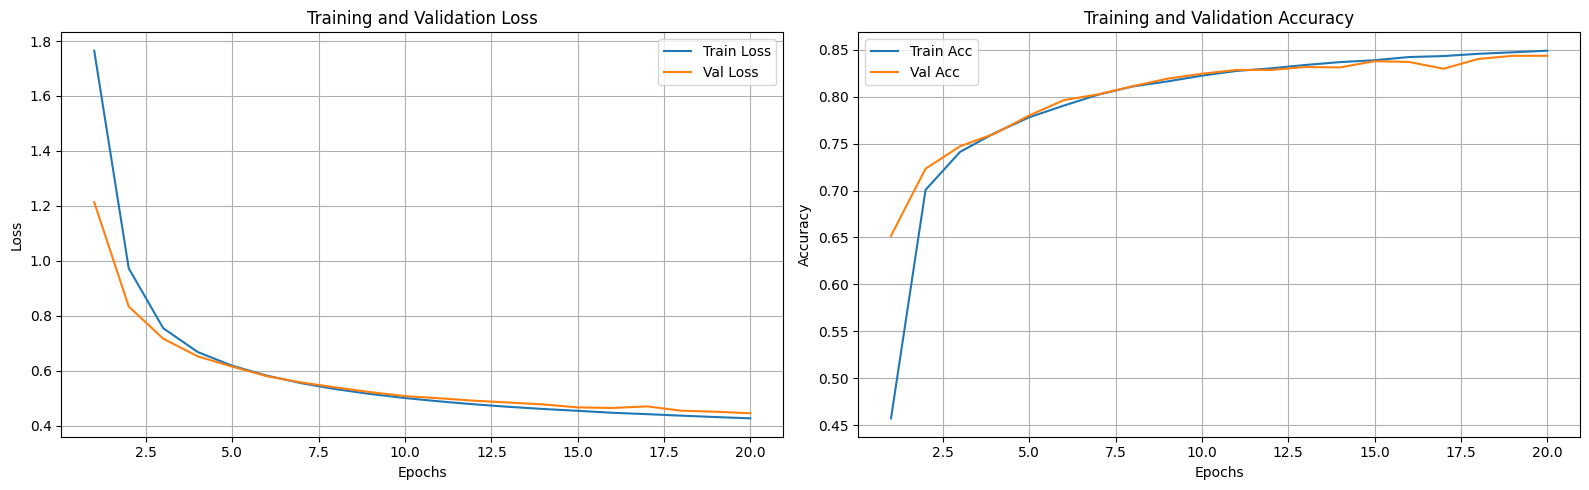

Test:
Loss: 0.46507332787513733
Acc: 0.8346


tensor([[ -5.3670,  -6.5754,  -5.4593,  ...,   6.7560,   2.5710,   7.2626],
        [  1.3952,  -1.8011,   8.9589,  ..., -11.8679,   0.1877,  -7.8025],
        [  2.4533,  12.3385,  -1.0105,  ...,  -4.4943,  -4.9588,  -7.1449],
        ...,
        [  2.5680,  -6.3424,  -0.9240,  ...,  -3.0144,   6.1056,  -4.8008],
        [ -0.0662,   9.9222,  -1.4688,  ...,  -2.2012,  -5.1138,  -4.1856],
        [ -4.0385,  -3.4051,  -2.2143,  ...,   3.0918,   1.3776,   0.0699]],
       device='cuda:0')

In [ ]:
MLP_no_dp = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerSize = TrainerTorch(model=MLP_no_dp,generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Z dropout:

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 2.0808 | Val Loss: 1.6479 | Val Acc: 0.5127
Epoch 2/20 | Train Loss: 1.5172 | Val Loss: 1.1116 | Val Acc: 0.6813
Epoch 3/20 | Train Loss: 1.2085 | Val Loss: 0.8996 | Val Acc: 0.7073
Epoch 4/20 | Train Loss: 1.0500 | Val Loss: 0.7988 | Val Acc: 0.7342
Epoch 5/20 | Train Loss: 0.9607 | Val Loss: 0.7346 | Val Acc: 0.7418
Epoch 6/20 | Train Loss: 0.8915 | Val Loss: 0.6946 | Val Acc: 0.7473
Epoch 7/20 | Train Loss: 0.8448 | Val Loss: 0.6667 | Val Acc: 0.7538
Epoch 8/20 | Train Loss: 0.8145 | Val Loss: 0.6433 | Val Acc: 0.7622
Epoch 9/20 | Train Loss: 0.7869 | Val Loss: 0.6273 | Val Acc: 0.7642
Epoch 10/20 | Train Loss: 0.7637 | Val Loss: 0.6127 | Val Acc: 0.7693
Epoch 11/20 | Train Loss: 0.7420 | Val Loss: 0.5989 | Val Acc: 0.7783
Epoch 12/20 | Train Loss: 0.7250 | Val Loss: 0.5840 | Val Acc: 0.7846
Epoch 13/20 | Train Loss: 0.7101 | Val Loss: 0.5735 | Val Acc: 0.7911
Epoch 14/20 | Train Loss: 0.6939 | Val Loss: 0.5609 | Val Acc: 0.7965


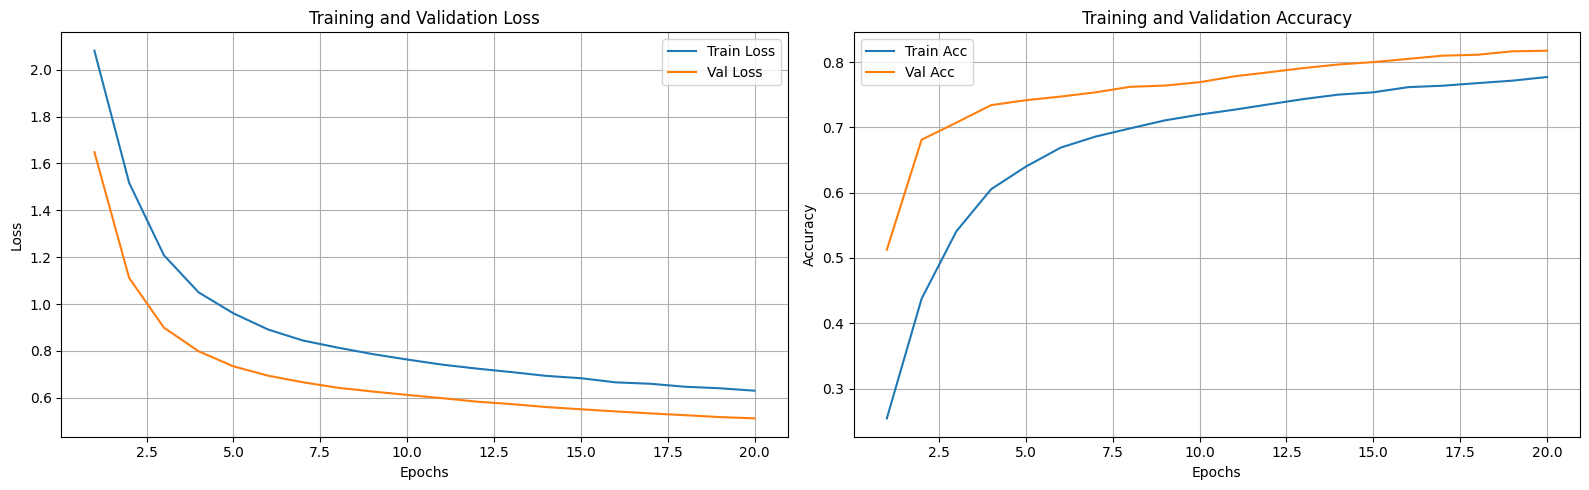

Test:
Loss: 0.5221108427047729
Acc: 0.8071


tensor([[-3.3747, -2.3344, -3.7953,  ...,  5.5640,  1.3378,  6.0648],
        [ 1.4287, -3.3117,  8.4359,  ..., -8.1962, -0.5336, -6.3475],
        [-0.8400, 13.0229,  1.2172,  ..., -0.6167, -8.4401, -1.9380],
        ...,
        [ 2.2425, -5.6013, -0.0824,  ..., -2.8503,  5.3752, -2.7655],
        [-1.3631,  9.8591, -0.0692,  ..., -0.0803, -6.5572, -1.3081],
        [-2.5823, -2.5477, -1.8841,  ...,  4.0034,  0.9818,  1.6130]],
       device='cuda:0')

In [ ]:
MLP_dp = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784, dropout=0.5)
TrainerSize = TrainerTorch(model=MLP_dp,generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Tutaj tak samo droput nie pomógł modelowi

* **Batch Normalization**
  Porównanie modelu:

  * z Batch Normalization,
  * bez Batch Normalization.

Bez Batch Normalization:

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.8936 | Val Loss: 1.3700 | Val Acc: 0.5665
Epoch 2/20 | Train Loss: 1.0738 | Val Loss: 0.8833 | Val Acc: 0.7192
Epoch 3/20 | Train Loss: 0.7817 | Val Loss: 0.7257 | Val Acc: 0.7438
Epoch 4/20 | Train Loss: 0.6777 | Val Loss: 0.6610 | Val Acc: 0.7642
Epoch 5/20 | Train Loss: 0.6257 | Val Loss: 0.6229 | Val Acc: 0.7776
Epoch 6/20 | Train Loss: 0.5915 | Val Loss: 0.5939 | Val Acc: 0.7874
Epoch 7/20 | Train Loss: 0.5652 | Val Loss: 0.5653 | Val Acc: 0.8007
Epoch 8/20 | Train Loss: 0.5441 | Val Loss: 0.5480 | Val Acc: 0.8101
Epoch 9/20 | Train Loss: 0.5263 | Val Loss: 0.5330 | Val Acc: 0.8168
Epoch 10/20 | Train Loss: 0.5111 | Val Loss: 0.5196 | Val Acc: 0.8191
Epoch 11/20 | Train Loss: 0.4977 | Val Loss: 0.5098 | Val Acc: 0.8205
Epoch 12/20 | Train Loss: 0.4866 | Val Loss: 0.4979 | Val Acc: 0.8264
Epoch 13/20 | Train Loss: 0.4766 | Val Loss: 0.4879 | Val Acc: 0.8293
Epoch 14/20 | Train Loss: 0.4682 | Val Loss: 0.4822 | Val Acc: 0.8299


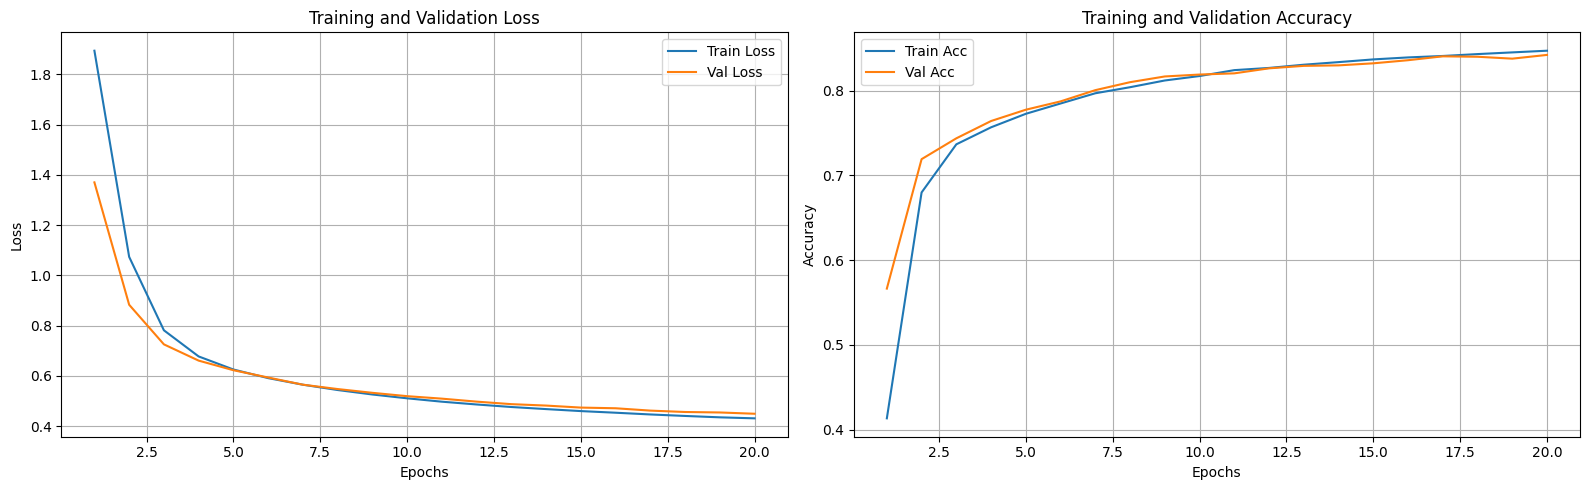

Test:
Loss: 0.46948822450637817
Acc: 0.8327


tensor([[ -4.5262,  -4.7132,  -4.3248,  ...,   7.2980,   3.2883,   8.1411],
        [  1.6142,  -2.1237,   8.4999,  ..., -10.0960,   1.9153,  -7.7050],
        [  3.8053,  13.6364,   1.2506,  ...,   1.2084,  -3.3037,  -5.4211],
        ...,
        [  3.7297,  -5.3785,  -0.6579,  ...,  -4.3050,   6.6280,  -5.1950],
        [  0.9394,  11.2753,   0.3416,  ...,   2.3683,  -4.4212,  -2.0766],
        [ -2.4086,  -2.7860,  -1.5305,  ...,   4.0280,   2.3701,   1.1822]],
       device='cuda:0')

In [ ]:
MLP_no_bn = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerSize = TrainerTorch(model=MLP_no_bn,generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Z Batch Normalization:

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.0806 | Val Loss: 0.7261 | Val Acc: 0.7837
Epoch 2/20 | Train Loss: 0.6262 | Val Loss: 0.5573 | Val Acc: 0.8257
Epoch 3/20 | Train Loss: 0.5109 | Val Loss: 0.4874 | Val Acc: 0.8415
Epoch 4/20 | Train Loss: 0.4553 | Val Loss: 0.4484 | Val Acc: 0.8517
Epoch 5/20 | Train Loss: 0.4228 | Val Loss: 0.4266 | Val Acc: 0.8567
Epoch 6/20 | Train Loss: 0.3996 | Val Loss: 0.4094 | Val Acc: 0.8612
Epoch 7/20 | Train Loss: 0.3817 | Val Loss: 0.4082 | Val Acc: 0.8587
Epoch 8/20 | Train Loss: 0.3687 | Val Loss: 0.3907 | Val Acc: 0.8639
Epoch 9/20 | Train Loss: 0.3549 | Val Loss: 0.3770 | Val Acc: 0.8705
Epoch 10/20 | Train Loss: 0.3453 | Val Loss: 0.3704 | Val Acc: 0.8731
Epoch 11/20 | Train Loss: 0.3343 | Val Loss: 0.3658 | Val Acc: 0.8710
Epoch 12/20 | Train Loss: 0.3264 | Val Loss: 0.3607 | Val Acc: 0.8731
Epoch 13/20 | Train Loss: 0.3174 | Val Loss: 0.3546 | Val Acc: 0.8769
Epoch 14/20 | Train Loss: 0.3093 | Val Loss: 0.3509 | Val Acc: 0.8780


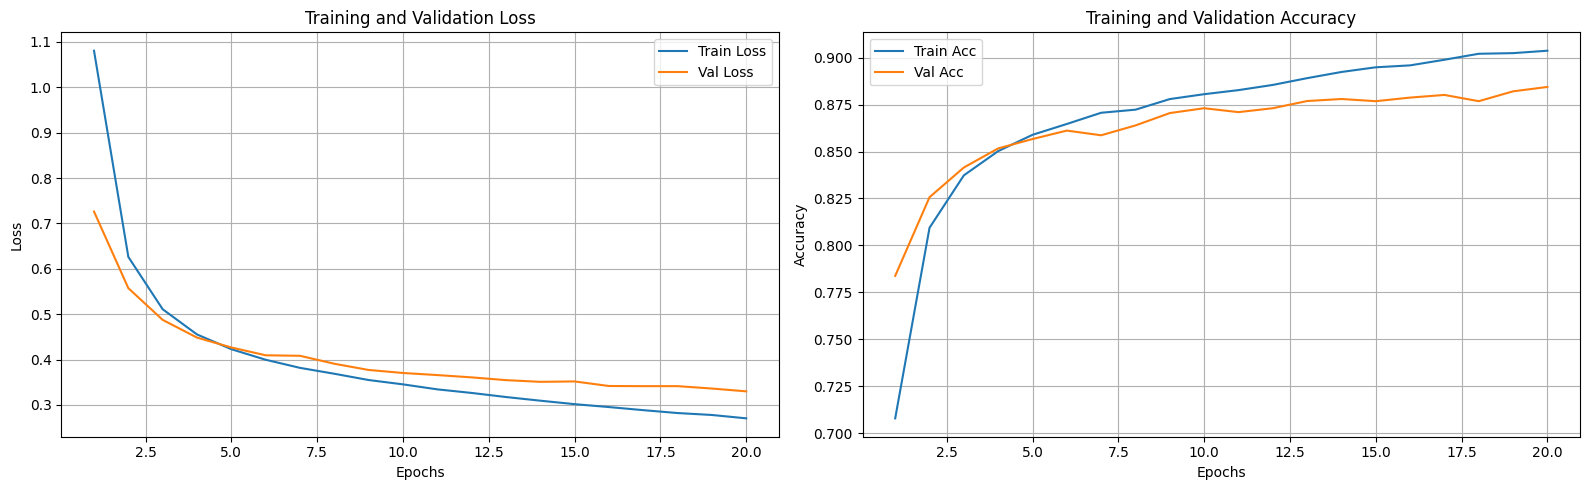

Test:
Loss: 0.3556385512948036
Acc: 0.8756


tensor([[-1.0202, -1.4856, -1.0880,  ...,  1.6702, -0.5993,  5.0878],
        [ 0.1098, -2.0768,  8.2680,  ..., -3.5504, -1.0854, -1.5580],
        [-0.2065,  8.7121, -1.1655,  ..., -1.5680, -0.7927, -1.6975],
        ...,
        [ 1.5629, -2.6557, -1.5508,  ..., -1.8994,  5.7860, -1.6541],
        [-0.8812,  8.7627, -1.2031,  ..., -1.9068, -1.3494, -1.3186],
        [-1.0756, -2.2223, -0.8693,  ...,  2.4900, -0.2058, -0.6449]],
       device='cuda:0')

In [ ]:
MLP_bn = ParametrizedMLP(BatchNormalization=True, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerSize = TrainerTorch(model=MLP_bn,generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

* **Optymalizator**
  Porównanie algorytmu optyalizującego wagi:
  * Adam (jako najczęściej stosowany w praktyce)
  * SGD (klasyczna metoda)

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 0.5646 | Val Loss: 0.4461 | Val Acc: 0.8430
Epoch 2/20 | Train Loss: 0.4130 | Val Loss: 0.3932 | Val Acc: 0.8568
Epoch 3/20 | Train Loss: 0.3760 | Val Loss: 0.3824 | Val Acc: 0.8640
Epoch 4/20 | Train Loss: 0.3489 | Val Loss: 0.3779 | Val Acc: 0.8664
Epoch 5/20 | Train Loss: 0.3442 | Val Loss: 0.3761 | Val Acc: 0.8683
Epoch 6/20 | Train Loss: 0.3232 | Val Loss: 0.3625 | Val Acc: 0.8702
Epoch 7/20 | Train Loss: 0.3178 | Val Loss: 0.3606 | Val Acc: 0.8731
Epoch 8/20 | Train Loss: 0.3111 | Val Loss: 0.3739 | Val Acc: 0.8704
Epoch 9/20 | Train Loss: 0.3066 | Val Loss: 0.3920 | Val Acc: 0.8673
Epoch 10/20 | Train Loss: 0.2964 | Val Loss: 0.3636 | Val Acc: 0.8738
Epoch 11/20 | Train Loss: 0.2934 | Val Loss: 0.3964 | Val Acc: 0.8674
Epoch 12/20 | Train Loss: 0.2956 | Val Loss: 0.3869 | Val Acc: 0.8714
Epoch 13/20 | Train Loss: 0.2939 | Val Loss: 0.3955 | Val Acc: 0.8663
Epoch 14/20 | Train Loss: 0.2826 | Val Loss: 0.3757 | Val Acc: 0.8711


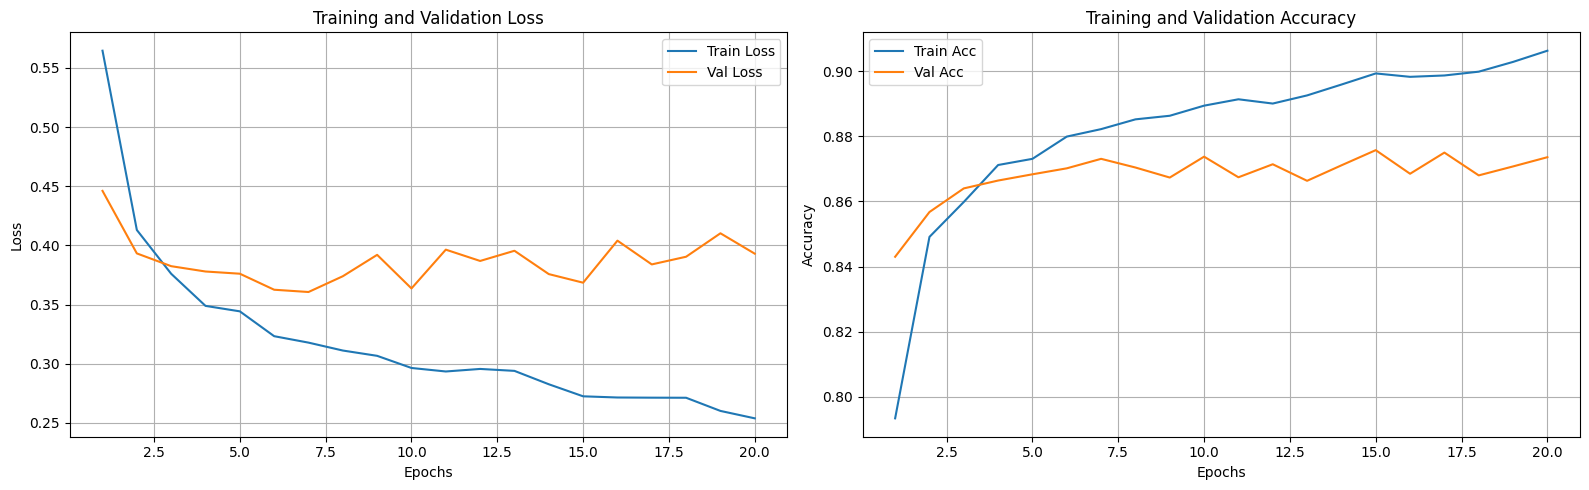

Test:
Loss: 0.37914302307367326
Acc: 0.8716


tensor([[-11.7832, -14.4708, -13.0793,  ...,   4.5548,  -8.7950,  10.7629],
        [ -1.0784, -11.4080,  12.6656,  ..., -13.8982,  -7.6868, -16.6525],
        [ -5.8120,  19.4158,  -5.2471,  ..., -56.8911, -19.4498, -28.5154],
        ...,
        [  1.8587,  -4.4804,  -0.5969,  ...,  -9.8279,   3.7859, -13.3313],
        [ -7.8329,  12.2063,  -4.3269,  ..., -27.5701,  -4.6547,  -5.0809],
        [ -2.0169,  -7.6341,  -3.2670,  ...,   0.4146,  -3.2777,  -3.2103]],
       device='cuda:0')

In [ ]:
MLP_adam = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerSize = TrainerTorch(model=MLP_adam,generator=g, optimizer="Adam")
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Tutaj jak widac Batch Norm pomógł w teorii modelowi, przy early stoppingu mogłem zatrzymac model w 3 epoce...

Rozpoczynam trening na: cuda
Epoch 1/20 | Train Loss: 1.8667 | Val Loss: 1.3337 | Val Acc: 0.6007
Epoch 2/20 | Train Loss: 1.0451 | Val Loss: 0.8669 | Val Acc: 0.7107
Epoch 3/20 | Train Loss: 0.7759 | Val Loss: 0.7273 | Val Acc: 0.7397
Epoch 4/20 | Train Loss: 0.6810 | Val Loss: 0.6655 | Val Acc: 0.7559
Epoch 5/20 | Train Loss: 0.6303 | Val Loss: 0.6271 | Val Acc: 0.7705
Epoch 6/20 | Train Loss: 0.5942 | Val Loss: 0.5941 | Val Acc: 0.7836
Epoch 7/20 | Train Loss: 0.5655 | Val Loss: 0.5690 | Val Acc: 0.7951
Epoch 8/20 | Train Loss: 0.5422 | Val Loss: 0.5445 | Val Acc: 0.8107
Epoch 9/20 | Train Loss: 0.5233 | Val Loss: 0.5281 | Val Acc: 0.8153
Epoch 10/20 | Train Loss: 0.5076 | Val Loss: 0.5172 | Val Acc: 0.8193
Epoch 11/20 | Train Loss: 0.4948 | Val Loss: 0.5079 | Val Acc: 0.8193
Epoch 12/20 | Train Loss: 0.4844 | Val Loss: 0.4969 | Val Acc: 0.8289
Epoch 13/20 | Train Loss: 0.4749 | Val Loss: 0.4876 | Val Acc: 0.8287
Epoch 14/20 | Train Loss: 0.4666 | Val Loss: 0.4894 | Val Acc: 0.8227


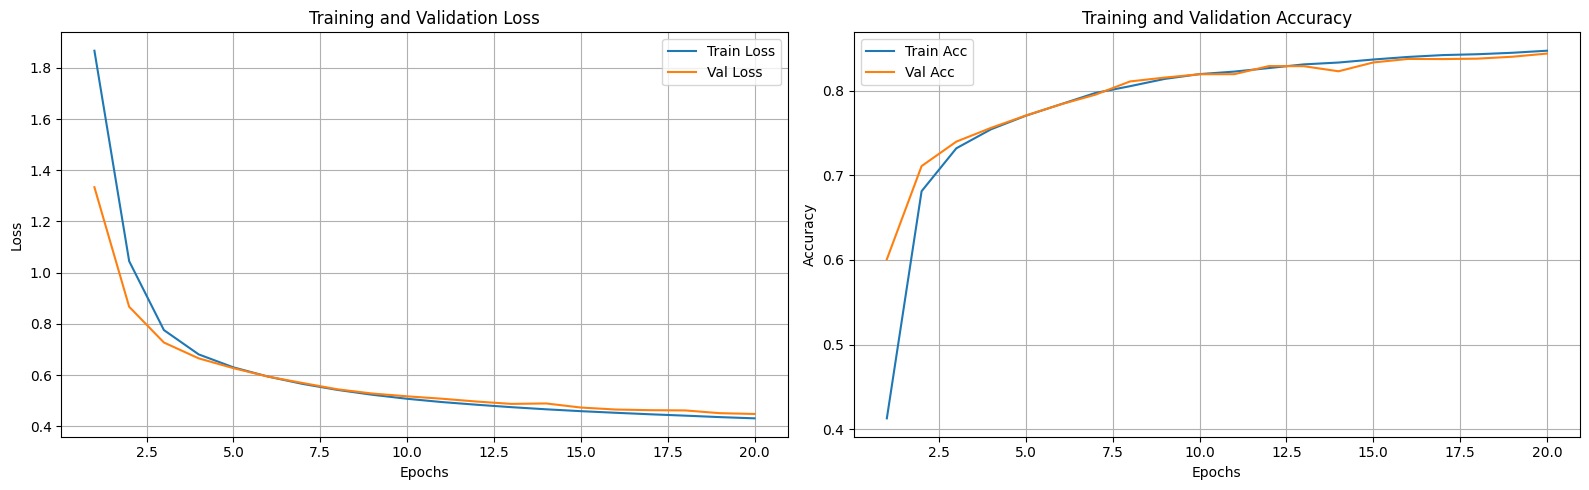

Test:
Loss: 0.4676989032745361
Acc: 0.8337


tensor([[ -3.9165,  -8.4266,  -3.8836,  ...,   7.1896,   3.3104,   7.8268],
        [  2.7129,   0.3577,  10.1526,  ..., -11.2504,   2.6954,  -8.2155],
        [  4.6003,  15.2558,   4.7333,  ...,  -8.4983,  -5.0290, -10.1986],
        ...,
        [  2.7478,  -6.7680,  -1.0476,  ...,  -0.7329,   6.8458,  -3.4664],
        [  1.3028,  11.3465,   2.2779,  ...,  -5.0463,  -5.3372,  -5.1207],
        [ -2.0797,  -4.1342,  -0.9654,  ...,   4.0612,   2.5355,   1.3104]],
       device='cuda:0')

In [ ]:
MLP_sgd = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerSize = TrainerTorch(model=MLP_sgd,generator=g)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

* **Scheduling learning rate**
  Eksperyment pokazujący wpływ harmonogramu zmiany learning rate.
  W tym przypadku warto również **logować wartość learning rate w kolejnych epokach**.

Rozpoczynam trening na: cuda
[0.00987726234834463]


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1427: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


Epoch 1/20 | Train Loss: 1.8791 | Val Loss: 1.3275 | Val Acc: 0.6147
[0.009575498965391208]
Epoch 2/20 | Train Loss: 1.0368 | Val Loss: 0.8650 | Val Acc: 0.7197
[0.009164023811348204]
Epoch 3/20 | Train Loss: 0.7747 | Val Loss: 0.7267 | Val Acc: 0.7408
[0.008652911674490298]
Epoch 4/20 | Train Loss: 0.6791 | Val Loss: 0.6625 | Val Acc: 0.7579
[0.008054688185447412]
Epoch 5/20 | Train Loss: 0.6293 | Val Loss: 0.6241 | Val Acc: 0.7752
[0.0073840196617494976]
Epoch 6/20 | Train Loss: 0.5958 | Val Loss: 0.5936 | Val Acc: 0.7884
[0.006657349821962693]
Epoch 7/20 | Train Loss: 0.5716 | Val Loss: 0.5734 | Val Acc: 0.7979
[0.005892492048157692]
Epoch 8/20 | Train Loss: 0.5531 | Val Loss: 0.5584 | Val Acc: 0.8052
[0.005108186821407397]
Epoch 9/20 | Train Loss: 0.5388 | Val Loss: 0.5449 | Val Acc: 0.8074
[0.004323634543204362]
Epoch 10/20 | Train Loss: 0.5273 | Val Loss: 0.5346 | Val Acc: 0.8140
[0.00355801405885981]
Epoch 11/20 | Train Loss: 0.5182 | Val Loss: 0.5273 | Val Acc: 0.8157
[0.002829

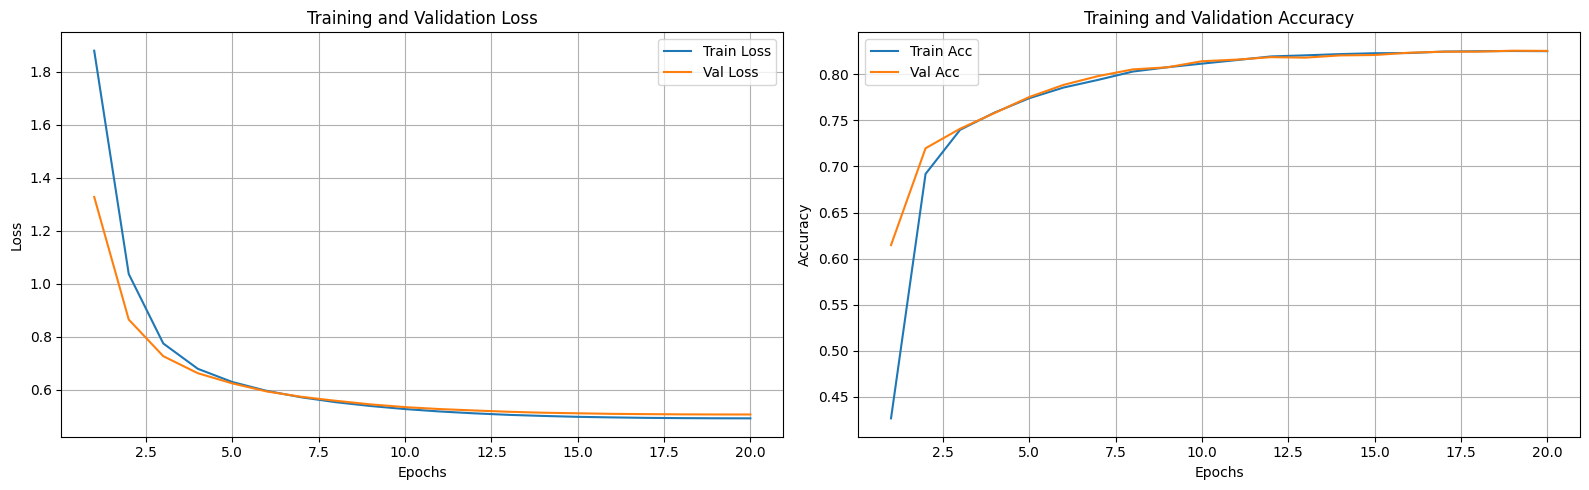

Test:
Loss: 0.5227911328792572
Acc: 0.8119


tensor([[-3.9794e+00, -5.7357e+00, -4.3160e+00,  ...,  6.2595e+00,
          2.7574e+00,  6.7056e+00],
        [ 5.0756e-01, -3.9033e+00,  8.8927e+00,  ..., -1.1086e+01,
          7.9095e-01, -7.6977e+00],
        [ 1.5397e+00,  1.2454e+01, -9.2628e-01,  ...,  5.9265e-02,
         -5.6844e+00, -5.3845e+00],
        ...,
        [ 2.2273e+00, -5.8707e+00, -9.8234e-01,  ..., -4.6619e+00,
          5.4101e+00, -3.7603e+00],
        [ 5.2142e-01,  8.7420e+00, -1.0413e+00,  ...,  1.1932e-02,
         -4.8071e+00, -3.7585e+00],
        [-2.9792e+00, -2.8129e+00, -1.9918e+00,  ...,  3.8450e+00,
          1.7971e+00,  1.0202e+00]], device='cuda:0')

In [ ]:
MLP_cosine = ParametrizedMLP(BatchNormalization=False, hiddenLayers=[100,100],outputSize=10,inputDim=784)
TrainerSize = TrainerTorch(model=MLP_cosine,generator=g, cosine_learning_rate=True)
TrainerSize.train(train_subset, val_subset)
print("Test:")
TrainerSize.predict(testset)

Podsumowanie
Oczekiwałem większych różnic między modelami, wyniki wszędzie wyszły bardzo zbliżone do siebie.

Może to być spowodowane błędem w robieniu pętli lub w innym miejscu, niestety nic nie znalazłem.